In [1]:
import os
import xarray as xr
import numpy as np
import matplotlib
#matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cmcrameri import cm as cmc
import cmocean as cmo
import pandas as pd
import matplotlib.patches as mpatches

SET INPUT OUTPUT FILES AND DIRS FOR PLOTTING

In [2]:
input_file = '/home/nicolas/SACO/FRESH-CARE/Codes/WP2/buongiorno_to_pytorch_padding/AA_winner_model_LSTM_52_46_bs16_lr2e-4_pat6x5_do0.2/mc_test_results.nc'
output_dir = '/home/nicolas/SACO/FRESH-CARE/Codes/WP2/buongiorno_to_pytorch_padding/AA_winner_model_LSTM_52_46_bs16_lr2e-4_pat6x5_do0.2/plots'
if not os.path.exists(input_file):
    raise FileNotFoundError(f"Input file not found: {input_file}")

In [3]:
results = xr.open_dataset(input_file)
os.makedirs(output_dir, exist_ok=True)
results

<xarray.Dataset> Size: 389MB
Dimensions:                (profile: 29371, depth: 91)
Coordinates:
  * profile                (profile) int64 235kB 0 1 2 3 ... 29368 29369 29370
  * depth                  (depth) float64 728B 0.0 5.0 10.0 ... 4.3e+03 4.4e+03
Data variables: (12/41)
    T_glorys               (profile, depth) float64 21MB ...
    S_glorys               (profile, depth) float64 21MB ...
    T_obs_anomaly          (profile, depth) float64 21MB ...
    S_obs_anomaly          (profile, depth) float64 21MB ...
    T_pred_anomaly         (profile, depth) float64 21MB ...
    S_pred_anomaly         (profile, depth) float64 21MB ...
    ...                     ...
    PSAL_aug_fraction      (profile) float32 117kB ...
    TEMP_augs              (profile, depth) float64 21MB ...
    PSAL_augs              (profile, depth) float64 21MB ...
    max_depth_idx          (profile) int64 235kB ...
    profile_lengths        (profile) int64 235kB ...
    ice_conc               (profile) float32 117kB ...
Attributes: (12/14)
    title:                       LSTM Model Test Results with Monte Carlo Dro...
    description:                 Comprehensive results including climatology,...
    model_architecture:          LSTM 52-46
    test_data_file:              /data/FRESH-CARE/data_for_LSTM/data/var_dept...
    MC_dropout_samples:          500
    output_variables:            ['temperature', 'salinity']
    ...                          ...
    n_depth_levels:              91
    glorys_rmse_real_data_only:  1
    T_rmse_total:                0.5128852467411663
    S_rmse_total:                0.2288903117319829
    training_time_seconds:       31104.72671031952
    mc_prediction_time_seconds:  1264.4261329174042

COMBINED T AND S RMSE BY DEPTH

/tmp/ipykernel_457540/502625698.py:37: RuntimeWarning: Mean of empty slice
  return np.sqrt(np.nanmean(diff**2, axis=0))


Saved plot to: /home/nicolas/SACO/FRESH-CARE/Codes/WP2/buongiorno_to_pytorch_padding/AA_winner_model_LSTM_52_46_bs16_lr2e-4_pat6x5_do0.2/plots/TS_rmse_by_depth_wnobs_ice_to400m.png


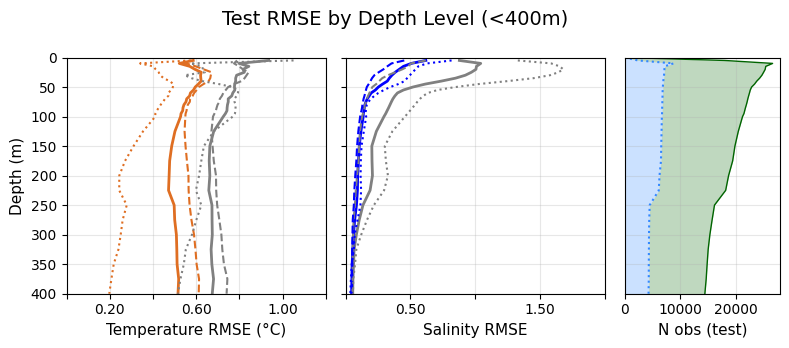

In [4]:

# Plot T and S RMSE by depth in a single figure
depths = results['depth'].values
depth_mask = np.ones(len(depths), dtype=bool)  # all depths
depth_mask = depths < 420 # uncomment if needed
legend = False
t_rmse_depths = results['T_rmse_depth'].values
t_rmse_depths_glorys = results['T_glorys_rmse_depth'].values
s_rmse_depths = results['S_rmse_depth'].values
s_rmse_depths_glorys = results['S_glorys_rmse_depth'].values

# Mask to real (non-augmented) profiles only
mask_real_t = results['TEMP_augs'].values == 0   # (n_profiles, n_depths)
mask_real_s = results['PSAL_augs'].values == 0

# N obs per depth from test dataset (real/non-augmented salinity)
n_obs_depth = np.sum(results['PSAL_augs'].values == 0, axis=0)

# Ice masks (per profile)
ice_conc = results['ice_conc'].values  # shape: (n_profiles,)
mask_ice_free = ice_conc <= 0
mask_ice_present = ice_conc > 0

# Split N obs per depth into ice-present and ice-free parts
n_obs_depth_ice_present = np.sum(mask_real_s & mask_ice_present[:, np.newaxis], axis=0)
n_obs_depth_ice_free = np.sum(mask_real_s & mask_ice_free[:, np.newaxis], axis=0)

# Compute RMSE by depth for ice-free and ice-present subsets using nanmean
T_pred_all = results['T_pred'].values       # (n_profiles, n_depths)
T_obs_all = results['T_obs_insitu'].values
T_glorys_all = results['T_glorys'].values
S_pred_all = results['S_pred'].values
S_glorys_all = results['S_glorys'].values

def rmse_by_depth(pred, obs, real_depth_mask, prof_mask):
    diff = np.where(real_depth_mask & np.isfinite(obs), pred - obs, np.nan)
    diff[~prof_mask, :] = np.nan
    return np.sqrt(np.nanmean(diff**2, axis=0))

t_rmse_ice_free    = rmse_by_depth(T_pred_all, T_obs_all, mask_real_t, mask_ice_free)
t_rmse_ice_present = rmse_by_depth(T_pred_all, T_obs_all, mask_real_t, mask_ice_present)
t_glorys_rmse_ice_free    = rmse_by_depth(T_glorys_all, T_obs_all, mask_real_t, mask_ice_free)
t_glorys_rmse_ice_present = rmse_by_depth(T_glorys_all, T_obs_all, mask_real_t, mask_ice_present)

s_rmse_ice_free    = rmse_by_depth(S_pred_all, results['S_obs_insitu'].values, mask_real_s, mask_ice_free)
s_rmse_ice_present = rmse_by_depth(S_pred_all, results['S_obs_insitu'].values, mask_real_s, mask_ice_present)
s_glorys_rmse_ice_free    = rmse_by_depth(S_glorys_all, results['S_obs_insitu'].values, mask_real_s, mask_ice_free)
s_glorys_rmse_ice_present = rmse_by_depth(S_glorys_all, results['S_obs_insitu'].values, mask_real_s, mask_ice_present)

fig, axes = plt.subplots(1, 3, figsize=(8, 3.5), sharey=True,
                         gridspec_kw={'width_ratios': [0.5, 0.5, 0.3]})

# Temperature panel: overall + ice-free (dashed) + ice-present (dotted)
axes[0].plot(t_rmse_depths_glorys[depth_mask], depths[depth_mask], 'gray', linewidth=2, label='GLORYS T RMSE')
axes[0].plot(t_rmse_depths[depth_mask], depths[depth_mask], '#DF6E22', linewidth=2, label='LSTM T RMSE')
axes[0].plot(t_glorys_rmse_ice_free[depth_mask], depths[depth_mask], 'gray', linewidth=1.5, linestyle='--', label='GLORYS T RMSE ice free')
axes[0].plot(t_rmse_ice_free[depth_mask], depths[depth_mask], '#DF6E22', linewidth=1.5, linestyle='--', label='LSTM T RMSE ice free')
axes[0].plot(t_glorys_rmse_ice_present[depth_mask], depths[depth_mask], 'gray', linewidth=1.5, linestyle=':', label='GLORYS T RMSE ice pres.')
axes[0].plot(t_rmse_ice_present[depth_mask], depths[depth_mask], '#DF6E22', linewidth=1.5, linestyle=':', label='LSTM T RMSE ice pres.')
axes[0].set_xlabel('Temperature RMSE (°C)', fontsize=11)
axes[0].set_ylabel('Depth (m)', fontsize=11)
if legend:
    axes[0].legend(fontsize=7, loc='lower right')
axes[0].grid(True, alpha=0.3)

# Salinity panel: overall + ice-free (dashed) + ice-present (dotted)
axes[1].plot(s_rmse_depths_glorys[depth_mask], depths[depth_mask], 'gray', linewidth=2, label='GLORYS S RMSE')
axes[1].plot(s_rmse_depths[depth_mask], depths[depth_mask], 'blue', linewidth=2, label='LSTM S RMSE')
axes[1].plot(s_glorys_rmse_ice_free[depth_mask], depths[depth_mask], 'gray', linewidth=1.5, linestyle='--', label='GLORYS S RMSE ice free')
axes[1].plot(s_rmse_ice_free[depth_mask], depths[depth_mask], 'blue', linewidth=1.5, linestyle='--', label='LSTM S RMSE ice free')
axes[1].plot(s_glorys_rmse_ice_present[depth_mask], depths[depth_mask], 'gray', linewidth=1.5, linestyle=':', label='GLORYS S RMSE ice pres.')
axes[1].plot(s_rmse_ice_present[depth_mask], depths[depth_mask], 'blue', linewidth=1.5, linestyle=':', label='LSTM S RMSE ice pres.')
axes[1].set_xlabel('Salinity RMSE', fontsize=11)
if legend:
    axes[1].legend(fontsize=7, loc='lower right')
axes[1].set_xlim(left=0)  # start x-axis at 0
axes[1].grid(True, alpha=0.3)

# Third panel: right-side half-violin split by ice-present and ice-free
axes[2].fill_betweenx(depths[depth_mask], 0, n_obs_depth_ice_present[depth_mask],
                      color="#3388FF", alpha=0.25, linewidth=0)
axes[2].fill_betweenx(depths[depth_mask], n_obs_depth_ice_present[depth_mask], n_obs_depth[depth_mask],
                      color='darkgreen', alpha=0.25, linewidth=0)
axes[2].plot(n_obs_depth_ice_present[depth_mask], depths[depth_mask], color="#3388FF",
              alpha=1, linewidth=1.5, linestyle=':', label='N obs ice pres.')
axes[2].plot(n_obs_depth[depth_mask], depths[depth_mask], color='darkgreen',
              alpha=1, linewidth=1, linestyle='-', label='N obs')
axes[2].set_xlabel('N obs (test)', fontsize=11)
handles, labels = axes[2].get_legend_handles_labels()
if legend:
    axes[2].legend(handles[::-1], labels[::-1], fontsize=7, loc='lower right')
axes[2].tick_params(axis='y', left=False)
axes[2].set_xlim(0, n_obs_depth[depth_mask].max() * 1.05)
axes[2].grid(True, alpha=0.3)

for ax in axes[:2]:
    xticks = ax.get_xticks()
    ax.set_xticks(xticks)
    ax.set_xticklabels([f'{tick:.2f}' if (i + 1) % 2 == 0 else '' for i, tick in enumerate(xticks)])

plot_bottom = min(depths[depth_mask].max(), 4000)
axes[0].set_ylim(plot_bottom, depths[depth_mask].min())  # inverted y-axis, capped at 4000 m
fig.suptitle('Test RMSE by Depth Level (<400m)', fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 1])
path = os.path.join(output_dir, 'TS_rmse_by_depth_wnobs_ice_to400m.png')
plt.savefig(path, dpi=350)
print(f"Saved plot to: {path}")
plt.show()


In [5]:
impr_T = results['T_glorys_rmse_depth'].values - results['T_rmse_depth'].values
iT = np.nanargmax(impr_T)
print("T max improvement at depth:", depths[iT], "m ; value:", impr_T[iT])

impr_S = results['S_glorys_rmse_depth'].values - results['S_rmse_depth'].values
iS = np.nanargmax(impr_S)
print("S max improvement at depth:", depths[iS], "m ; value:", impr_S[iS])

impr_T_ice_present = t_glorys_rmse_ice_present - t_rmse_ice_present
iT_ice_present = np.nanargmax(impr_T_ice_present)
print("T max improvement (ice present) at depth:", depths[iT_ice_present], "m ; value:", impr_T_ice_present[iT_ice_present])

impr_S_ice_present = s_glorys_rmse_ice_present - s_rmse_ice_present
iS_ice_present = np.nanargmax(impr_S_ice_present)
print("S max improvement (ice present) at depth:", depths[iS_ice_present], "m ; value:", impr_S_ice_present[iS_ice_present])


T max improvement at depth: 950.0 m ; value: 0.38466253954273966
S max improvement at depth: 20.0 m ; value: 0.5917382131502087
T max improvement (ice present) at depth: 5.0 m ; value: 0.4760664323054108
S max improvement (ice present) at depth: 20.0 m ; value: 1.1405294784781501


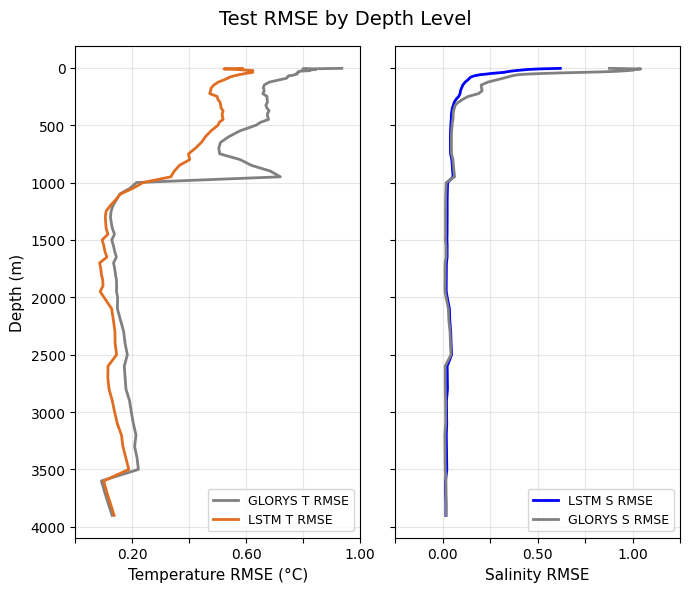

In [6]:

# Plot T and S RMSE by depth in a single figure
depths = results['depth'].values
depth_mask = np.ones(depths.shape, dtype=bool) # optionally mask depths
#depth_mask = depths > 500
t_rmse_depths = results['T_rmse_depth'].values
t_rmse_depths_glorys = results['T_glorys_rmse_depth'].values
s_rmse_depths = results['S_rmse_depth'].values
s_rmse_depths_glorys = results['S_glorys_rmse_depth'].values

fig, axes = plt.subplots(1, 2, figsize=(7, 6), sharey=True)

axes[0].plot(t_rmse_depths_glorys[depth_mask], depths[depth_mask], 'gray', linewidth=2, label='GLORYS T RMSE')
axes[0].plot(t_rmse_depths[depth_mask], depths[depth_mask], '#DF6E22', linewidth=2, label='LSTM T RMSE')
axes[0].set_xlabel('Temperature RMSE (°C)', fontsize=11)
axes[0].set_ylabel('Depth (m)', fontsize=11)
axes[0].legend(fontsize=9, loc='lower right')
axes[0].grid(True, alpha=0.3)

axes[1].plot(s_rmse_depths[depth_mask], depths[depth_mask], 'blue', linewidth=2, label='LSTM S RMSE')
axes[1].plot(s_rmse_depths_glorys[depth_mask], depths[depth_mask], 'gray', linewidth=2, label='GLORYS S RMSE')
axes[1].set_xlabel('Salinity RMSE', fontsize=11)
axes[1].legend(fontsize=9, loc='lower right')
axes[1].grid(True, alpha=0.3)

for ax in axes:
    xticks = ax.get_xticks()
    ax.set_xticks(xticks)
    ax.set_xticklabels([f'{tick:.2f}' if (i + 1) % 2 == 0 else '' for i, tick in enumerate(xticks)])

axes[0].invert_yaxis()
fig.suptitle('Test RMSE by Depth Level', fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 1])
path = os.path.join(output_dir, 'TS_rmse_by_depth.png')
plt.savefig(path, dpi=350)
plt.show()


PLOT RMSE BY DEPTH AND SEASON:

/tmp/ipykernel_457540/686333945.py:40: RuntimeWarning: Mean of empty slice
  return np.sqrt(np.nanmean(diff ** 2, axis=0))


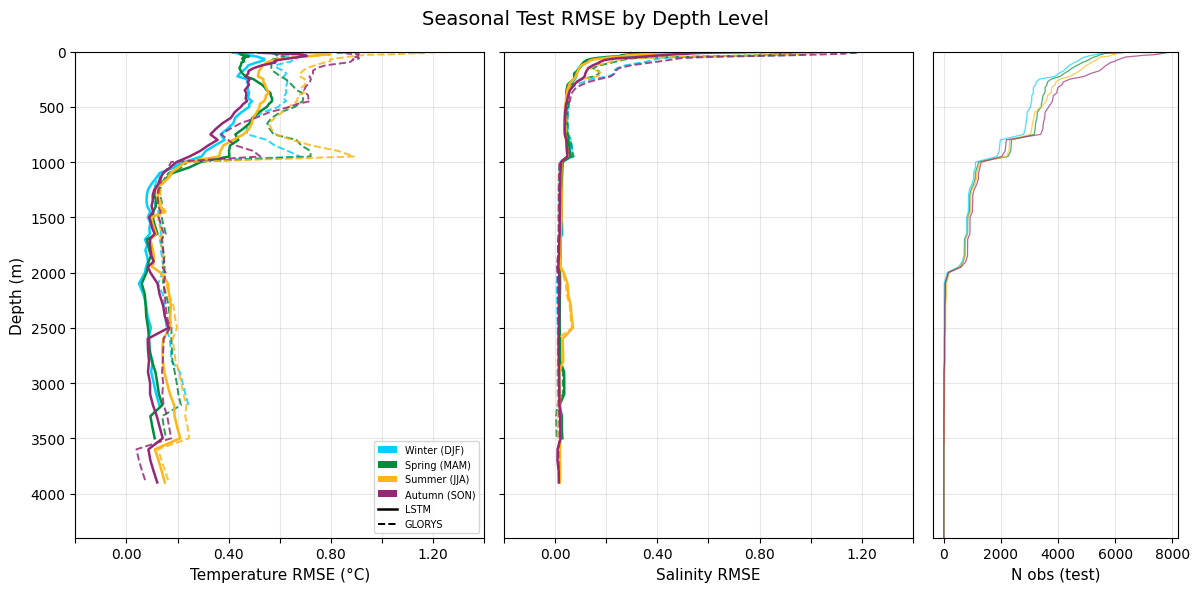

In [7]:
# --- Season masks ---
time_vals = pd.DatetimeIndex(results['TIME'].values)
months = time_vals.month

seasons = {
    'DJF': np.isin(months, [12, 1, 2]),
    'MAM': np.isin(months, [3, 4, 5]),
    'JJA': np.isin(months, [6, 7, 8]),
    'SON': np.isin(months, [9, 10, 11]),
}
season_colors = {
    'DJF': "#00d0ff",   # turquoise
    'MAM': "#008C3A",   # green
    'JJA': "#ffb515",   # ochre
    'SON': "#962775",   # brownish orange
}
season_labels = {'DJF': 'Winter (DJF)', 'MAM': 'Spring (MAM)',
                 'JJA': 'Summer (JJA)', 'SON': 'Autumn (SON)'}

# --- Seasonal RMSE by depth (real in-situ data only) ---
depths = results['depth'].values
depth_mask = np.ones(len(depths), dtype=bool)  # all depths
#depth_mask = depths < 500  # uncomment to restrict

T_pred_all  = results['T_pred'].values
T_obs_all   = results['T_obs_insitu'].values
T_glorys_all = results['T_glorys'].values
S_pred_all  = results['S_pred'].values
S_obs_all   = results['S_obs_insitu'].values
S_glorys_all = results['S_glorys'].values

# Mask to real (non-augmented) profiles only
mask_real_t = results['TEMP_augs'].values == 0   # (n_profiles, n_depths)
mask_real_s = results['PSAL_augs'].values == 0

def rmse_by_depth_seasonal(pred, obs, real_depth_mask, prof_mask):
    """RMSE by depth restricted to real in-situ obs for profiles in prof_mask."""
    diff = np.where(real_depth_mask & np.isfinite(obs), pred - obs, np.nan)
    diff[~prof_mask, :] = np.nan
    return np.sqrt(np.nanmean(diff ** 2, axis=0))

seasonal_T_rmse, seasonal_T_glorys_rmse = {}, {}
seasonal_S_rmse, seasonal_S_glorys_rmse = {}, {}
seasonal_nobs = {}

for sname, smask in seasons.items():
    seasonal_T_rmse[sname]        = rmse_by_depth_seasonal(T_pred_all,  T_obs_all,  mask_real_t, smask)
    seasonal_T_glorys_rmse[sname] = rmse_by_depth_seasonal(T_glorys_all, T_obs_all, mask_real_t, smask)
    seasonal_S_rmse[sname]        = rmse_by_depth_seasonal(S_pred_all,  S_obs_all,  mask_real_s, smask)
    seasonal_S_glorys_rmse[sname] = rmse_by_depth_seasonal(S_glorys_all, S_obs_all, mask_real_s, smask)
    seasonal_nobs[sname] = np.sum(np.isfinite(S_obs_all) & mask_real_s & smask[:, np.newaxis], axis=0)

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(12, 6), sharey=True,
                         gridspec_kw={'width_ratios': [0.5, 0.5, 0.3]})

for sname in ['DJF', 'MAM', 'JJA', 'SON']:
    c = season_colors[sname]
    lbl = season_labels[sname]

    # Temperature panel
    axes[0].plot(seasonal_T_glorys_rmse[sname][depth_mask], depths[depth_mask],
                 color=c, linewidth=1.4, linestyle='--', alpha=0.85)
    axes[0].plot(seasonal_T_rmse[sname][depth_mask], depths[depth_mask],
                 color=c, linewidth=1.8, linestyle='-', label=lbl)

    # Salinity panel
    axes[1].plot(seasonal_S_glorys_rmse[sname][depth_mask], depths[depth_mask],
                 color=c, linewidth=1.4, linestyle='--', alpha=0.85)
    axes[1].plot(seasonal_S_rmse[sname][depth_mask], depths[depth_mask],
                 color=c, linewidth=1.8, linestyle='-', label=lbl)

    # N obs violin (right panel)
    axes[2].plot(seasonal_nobs[sname][depth_mask], depths[depth_mask],
                 color=c, linewidth=0.9, alpha=0.7)

axes[0].set_xlabel('Temperature RMSE (°C)', fontsize=11)
axes[0].set_ylabel('Depth (m)', fontsize=11)
axes[0].grid(True, alpha=0.3)

# Legend: season colour rectangles + line style entries
from matplotlib.lines import Line2D
season_handles = [mpatches.Patch(facecolor=season_colors[s], label=season_labels[s])
                  for s in ['DJF', 'MAM', 'JJA', 'SON']]
style_handles  = [Line2D([0], [0], color='k', linewidth=1.8, linestyle='-',  label='LSTM'),
                  Line2D([0], [0], color='k', linewidth=1.4, linestyle='--', label='GLORYS')]
axes[0].legend(handles=season_handles + style_handles, fontsize=7, loc='lower right')

axes[1].set_xlabel('Salinity RMSE', fontsize=11)
axes[1].grid(True, alpha=0.3)

axes[2].set_xlabel('N obs (test)', fontsize=11)
axes[2].tick_params(axis='y', left=False)
axes[2].grid(True, alpha=0.3)

for ax in axes[:2]:
    xticks = ax.get_xticks()
    ax.set_xticks(xticks)
    ax.set_xticklabels([f'{tick:.2f}' if (i + 1) % 2 == 0 else '' for i, tick in enumerate(xticks)])

axes[0].set_ylim(depths[depth_mask].max(), depths[depth_mask].min())
fig.suptitle('Seasonal Test RMSE by Depth Level', fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 1])
path = os.path.join(output_dir, 'TS_rmse_by_depth_seasonal.png')
plt.savefig(path, dpi=350)
plt.show()


PLOT T RMSE BY PROFILE:

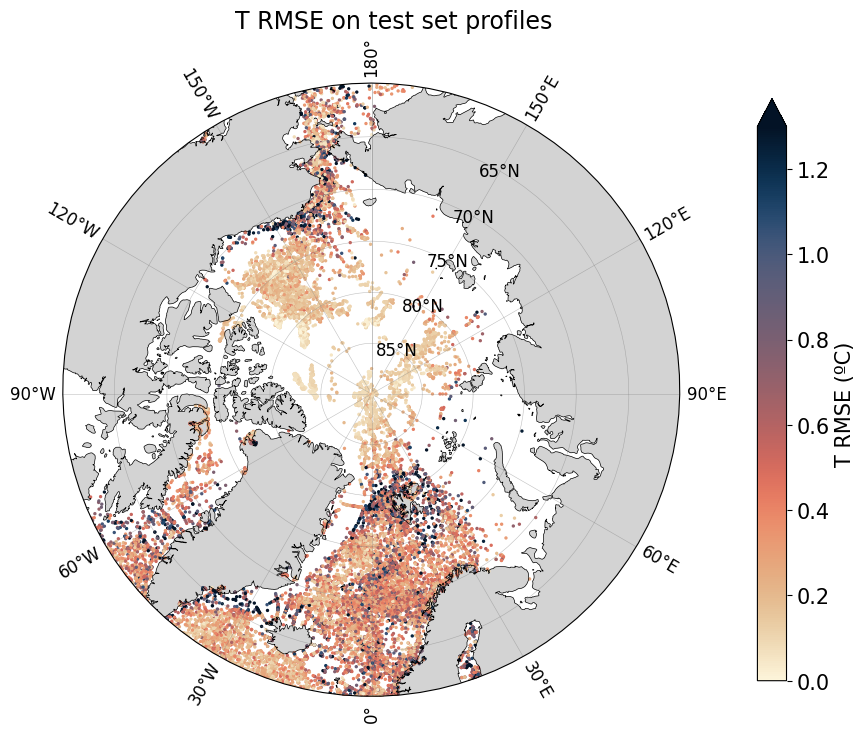

In [16]:
# Extract lat/lon
lats = results['LATITUDE'].values
lons = results['LONGITUDE'].values
values = results['T_rmse_profile'].values

# Create figure and Arctic projection
fig = plt.figure(figsize=(9, 10))
ax = plt.axes(projection=ccrs.NorthPolarStereo())

# Set extent: Northern Hemisphere only
ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())

# Add features
ax.add_feature(
cfeature.LAND
, facecolor='lightgray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.5)
gl.xlocator = plt.MultipleLocator(30)  # Longitude every 30 degrees
gl.ylocator = plt.MultipleLocator(5)  # Latitude every 10 degrees
gl.xlabel_style = {'size': 12}
gl.ylabel_style = {'size': 12}

# Add circle boundary (matching your existing functions)
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

sc = ax.scatter(
    lons, lats,
    c = values,
    s = 2,
    cmap ='cmc.lipari_r',
    transform=ccrs.PlateCarree(),
    vmin=0.0, vmax=1.3
)

cbar = plt.colorbar(sc, ax=ax, orientation='vertical', pad=0.095, shrink=0.6, location='right', extend='max')
cbar.set_label('T RMSE (ºC)', fontsize=15)
cbar.ax.tick_params(labelsize=15)
plt.title("      T RMSE on test set profiles", fontsize=17)
plt.tight_layout()
path = os.path.join(output_dir, 'T_rmse_map.png')
plt.savefig(path, dpi=350)
plt.show()


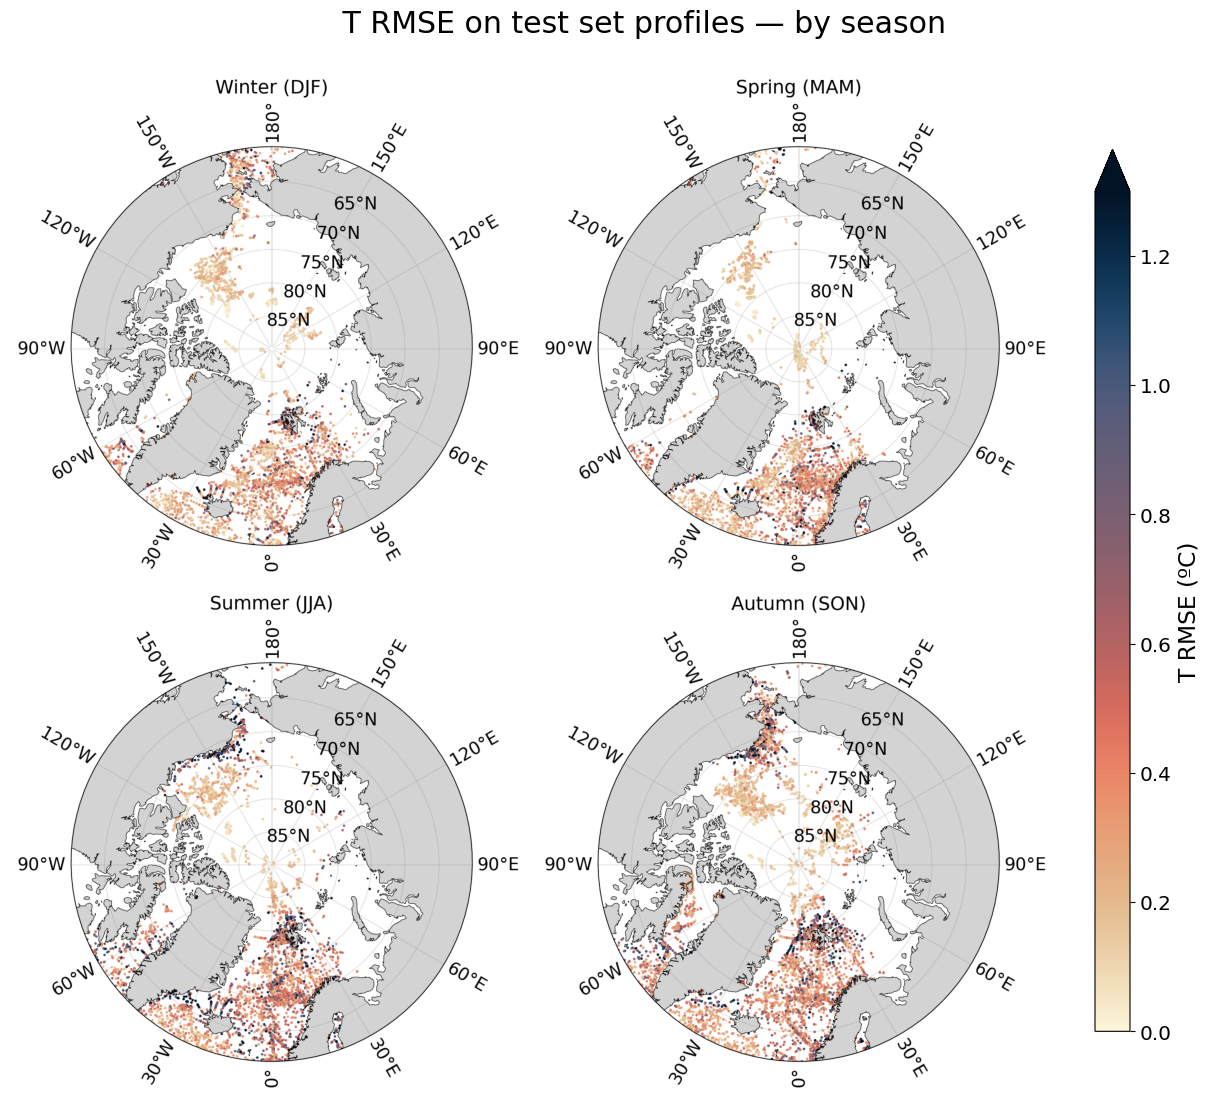

In [10]:
# --- Season masks ---
time_vals = pd.DatetimeIndex(results['TIME'].values)
months = time_vals.month
seasons = {
    'DJF': np.isin(months, [12, 1, 2]),
    'MAM': np.isin(months, [3, 4, 5]),
    'JJA': np.isin(months, [6, 7, 8]),
    'SON': np.isin(months, [9, 10, 11]),
}
season_labels = {'DJF': 'Winter (DJF)', 'MAM': 'Spring (MAM)',
                 'JJA': 'Summer (JJA)', 'SON': 'Autumn (SON)'}

lats = results['LATITUDE'].values
lons = results['LONGITUDE'].values
values_all = results['T_rmse_profile'].values

vmin, vmax = 0.0, 1.3

import io
import matplotlib.cm as _cm
import matplotlib.colors as _mcolors

panel_imgs = []
for sname in ['DJF', 'MAM', 'JJA', 'SON']:
    smask = seasons[sname]

    _fig = plt.figure(figsize=(7, 8))
    _ax = plt.axes(projection=ccrs.NorthPolarStereo())
    _ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())
    _ax.add_feature(cfeature.LAND, facecolor='lightgray')
    _ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    _gl = _ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.5)
    _gl.xlocator = plt.MultipleLocator(30)
    _gl.ylocator = plt.MultipleLocator(5)
    _gl.xlabel_style = {'size': 16.8}
    _gl.ylabel_style = {'size': 16.8}
    _theta = np.linspace(0, 2 * np.pi, 100)
    _verts = np.vstack([np.sin(_theta), np.cos(_theta)]).T
    _circle = mpath.Path(_verts * 0.5 + [0.5, 0.5])
    _ax.set_boundary(_circle, transform=_ax.transAxes)
    _ax.scatter(
        lons[smask], lats[smask],
        c=values_all[smask], s=2,
        cmap='cmc.lipari_r',
        transform=ccrs.PlateCarree(),
        vmin=vmin, vmax=vmax
    )
    _ax.set_title(season_labels[sname], fontsize=18)
    _fig.tight_layout()

    buf = io.BytesIO()
    _fig.savefig(buf, dpi=150, bbox_inches='tight')
    buf.seek(0)
    panel_imgs.append(plt.imread(buf))
    plt.close(_fig)

# Composite 2×2, with explicit right margin for colorbar and vertical gap between rows
fig, axes = plt.subplots(2, 2, figsize=(14, 14))
for ax, img in zip(axes.flatten(), panel_imgs):
    ax.imshow(img)
    ax.axis('off')

fig.suptitle(('                       ' 
              'T RMSE on test set profiles — by season'), fontsize=21.6, y=0.95)

fig.subplots_adjust(top=0.97, right=0.87, hspace=-0.25, wspace=0.02)

_sm = _cm.ScalarMappable(cmap='cmc.lipari_r', norm=_mcolors.Normalize(vmin=vmin, vmax=vmax))
_sm.set_array([])
cbar_ax = fig.add_axes([0.90, 0.22, 0.025, 0.63])
cbar = fig.colorbar(_sm, cax=cbar_ax, extend='max')
cbar.set_label('T RMSE (ºC)', fontsize=16.8)
cbar.ax.tick_params(labelsize=14.4)

path = os.path.join(output_dir, 'T_rmse_map_seasonal.png')
plt.savefig(path, dpi=200, bbox_inches='tight')
plt.show()


PLOT IMPROVEMENT RELATIVE TO GLORYS BY PROFILE

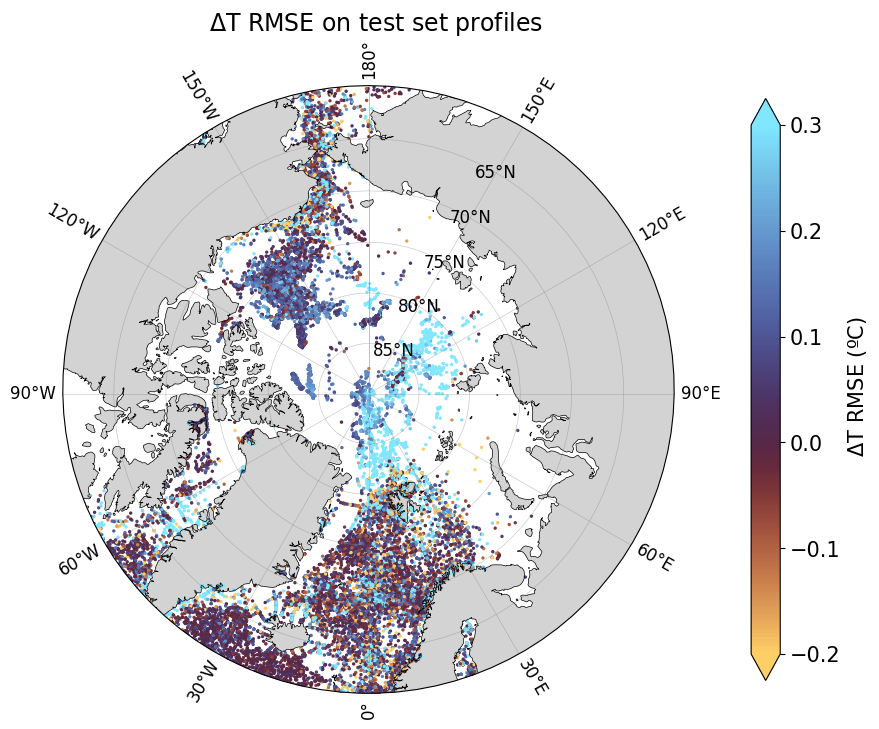

In [17]:

# Extract lat/lon
lats = results['LATITUDE'].values
lons = results['LONGITUDE'].values
values = results['T_glorys_rmse_profile'].values - results['T_rmse_profile'].values

# Create figure and Arctic projection
fig = plt.figure(figsize=(9, 10))
ax = plt.axes(projection=ccrs.NorthPolarStereo())

# Set extent: Northern Hemisphere only
ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())

# Add features
ax.add_feature(
cfeature.LAND
, facecolor='lightgray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.5)
gl.xlocator = plt.MultipleLocator(30)  # Longitude every 30 degrees
gl.ylocator = plt.MultipleLocator(5)  # Latitude every 10 degrees
gl.xlabel_style = {'size': 12}
gl.ylabel_style = {'size': 12}

# Add circle boundary (matching your existing functions)
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

# Remap managua so the center color (originally at 0.5) sits at 2/5 of the colormap
_cf = 2/5
_n = 256
_n_neg = round(_n * _cf)
_cmap_colors = np.vstack([
    cmc.managua(np.linspace(0, 0.5, _n_neg)),
    cmc.managua(np.linspace(0.5, 1.0, _n - _n_neg))
])
cmap_asym = matplotlib.colors.LinearSegmentedColormap.from_list("managua_asym", _cmap_colors)

# Custom norm: maps vmin→0, vcenter=0→2/5, vmax→1
class _AsymNorm(matplotlib.colors.Normalize):
    def __init__(self, vmin, vcenter, vmax, cf=2/5):
        self._vc, self._cf = vcenter, cf
        super().__init__(vmin, vmax)
    def __call__(self, value, clip=None):
        v = np.ma.asarray(value)
        result = np.interp(v.filled(np.nan), [self.vmin, self._vc, self.vmax], [0, self._cf, 1])
        return np.ma.array(result, mask=np.ma.getmaskarray(v))
    def inverse(self, value):
        return np.interp(value, [0, self._cf, 1], [self.vmin, self._vc, self.vmax])

norm = _AsymNorm(vmin=-0.20, vcenter=0, vmax=0.3, cf=2/5)

sc = ax.scatter(
    lons, lats,
    c = values,
    s = 2,
    cmap = cmap_asym,
    transform=ccrs.PlateCarree(),
    norm=norm
)

cbar = plt.colorbar(sc, ax=ax, orientation='vertical', pad=0.095, shrink=0.6, location='right', extend='both')
cbar.set_label(r' $\Delta$T RMSE (ºC)', fontsize=15)
cbar.set_ticks([-0.2, -0.1, 0.0, 0.1, 0.2, 0.3])
cbar.ax.tick_params(labelsize=15)
plt.title(r"  $\Delta$T RMSE on test set profiles", fontsize=17)
plt.tight_layout()
path = os.path.join(output_dir, 'T_rmse_improvement_map.png')
plt.savefig(path, dpi=350)
plt.show()


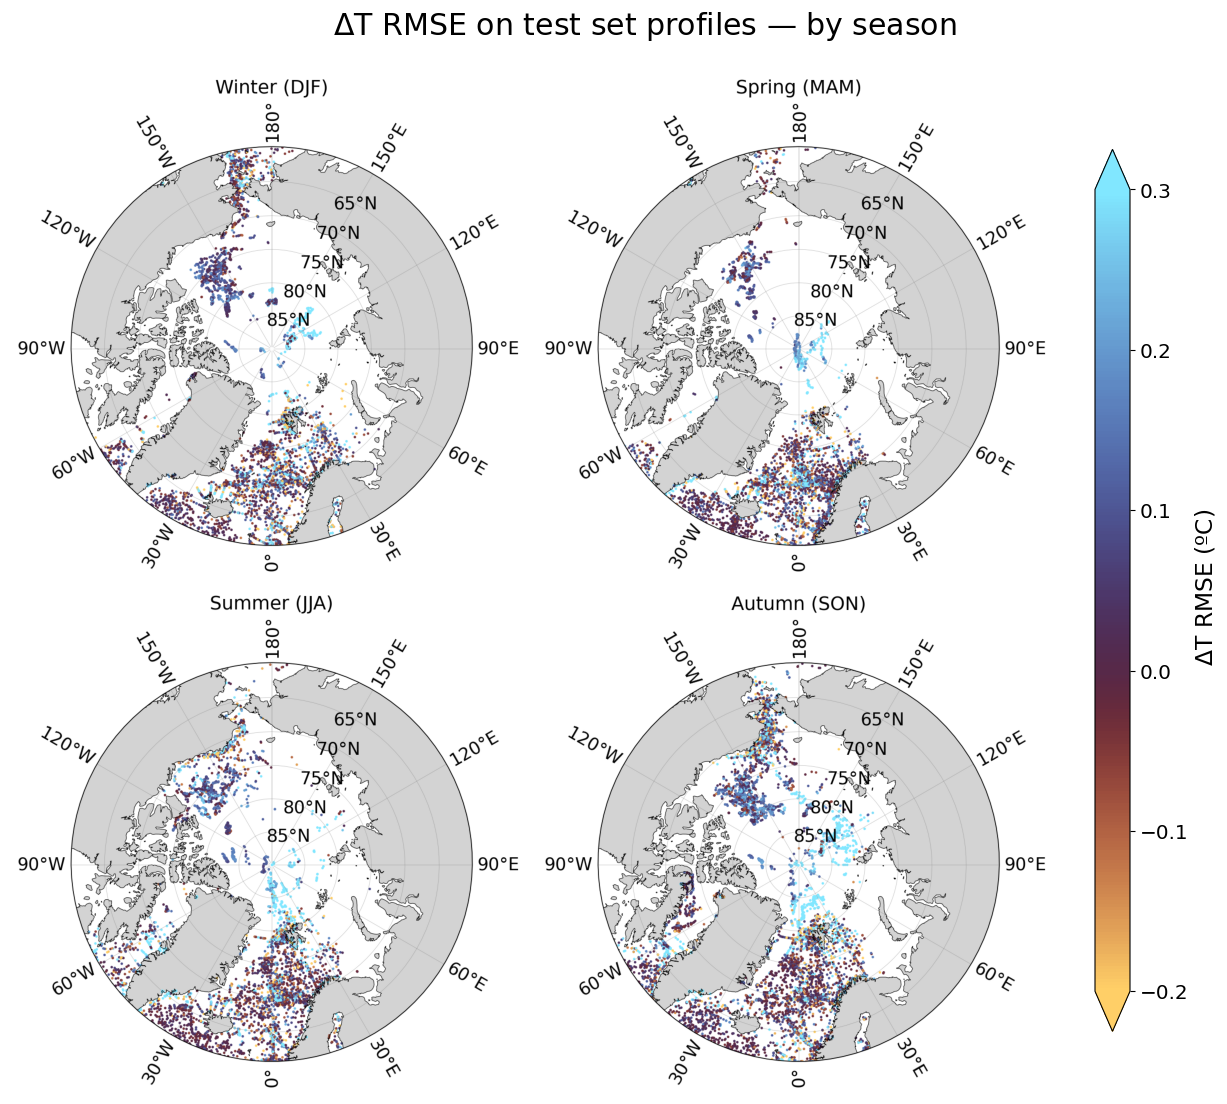

In [20]:

## --- Season masks ---
time_vals = pd.DatetimeIndex(results['TIME'].values)
months = time_vals.month
seasons = {
    'DJF': np.isin(months, [12, 1, 2]),
    'MAM': np.isin(months, [3, 4, 5]),
    'JJA': np.isin(months, [6, 7, 8]),
    'SON': np.isin(months, [9, 10, 11]),
}
season_labels = {'DJF': 'Winter (DJF)', 'MAM': 'Spring (MAM)',
                 'JJA': 'Summer (JJA)', 'SON': 'Autumn (SON)'}

lats = results['LATITUDE'].values
lons = results['LONGITUDE'].values
values_all = results['T_glorys_rmse_profile'].values - results['T_rmse_profile'].values

# Asymmetric managua colormap: center (zero) at 2/5 of the colormap range
import io
import matplotlib.cm as _cm
import matplotlib.colors as _mcolors

_cf = 2/5
_n = 256
_n_neg = round(_n * _cf)
_cmap_colors = np.vstack([
    cmc.managua(np.linspace(0, 0.5, _n_neg)),
    cmc.managua(np.linspace(0.5, 1.0, _n - _n_neg))
])
cmap_asym = matplotlib.colors.LinearSegmentedColormap.from_list("managua_asym", _cmap_colors)

class _AsymNorm(matplotlib.colors.Normalize):
    def __init__(self, vmin, vcenter, vmax, cf=2/5):
        self._vc, self._cf = vcenter, cf
        super().__init__(vmin, vmax)
    def __call__(self, value, clip=None):
        v = np.ma.asarray(value)
        result = np.interp(v.filled(np.nan), [self.vmin, self._vc, self.vmax], [0, self._cf, 1])
        return np.ma.array(result, mask=np.ma.getmaskarray(v))
    def inverse(self, value):
        return np.interp(value, [0, self._cf, 1], [self.vmin, self._vc, self.vmax])

norm = _AsymNorm(vmin=-0.20, vcenter=0, vmax=0.3, cf=2/5)

# Build each panel as a standalone figure, capture as image, then composite
panel_imgs = []
for sname in ['DJF', 'MAM', 'JJA', 'SON']:
    smask = seasons[sname]

    _fig = plt.figure(figsize=(7, 8))
    _ax = plt.axes(projection=ccrs.NorthPolarStereo())
    _ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())
    _ax.add_feature(cfeature.LAND, facecolor='lightgray')
    _ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    _gl = _ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.5)
    _gl.xlocator = plt.MultipleLocator(30)
    _gl.ylocator = plt.MultipleLocator(5)
    _gl.xlabel_style = {'size': 16.8}
    _gl.ylabel_style = {'size': 16.8}
    _theta = np.linspace(0, 2 * np.pi, 100)
    _verts = np.vstack([np.sin(_theta), np.cos(_theta)]).T
    _circle = mpath.Path(_verts * 0.5 + [0.5, 0.5])
    _ax.set_boundary(_circle, transform=_ax.transAxes)
    _ax.scatter(
        lons[smask], lats[smask],
        c=values_all[smask], s=2,
        cmap=cmap_asym,
        transform=ccrs.PlateCarree(),
        norm=norm
    )
    _ax.set_title(season_labels[sname], fontsize=18)
    _fig.tight_layout()

    buf = io.BytesIO()
    _fig.savefig(buf, dpi=150, bbox_inches='tight')
    buf.seek(0)
    panel_imgs.append(plt.imread(buf))
    plt.close(_fig)

# Composite 2×2
fig, axes = plt.subplots(2, 2, figsize=(14, 14))
for ax, img in zip(axes.flatten(), panel_imgs):
    ax.imshow(img)
    ax.axis('off')

fig.suptitle(r'                       $\Delta$T RMSE on test set profiles — by season', fontsize=21.6, y=0.95)
fig.subplots_adjust(top=0.97, right=0.87, hspace=-0.25, wspace=0.02)

# Shared colorbar
_sm = _cm.ScalarMappable(cmap=cmap_asym, norm=norm)
_sm.set_array([])
cbar_ax = fig.add_axes([0.90, 0.22, 0.025, 0.63])
cbar = fig.colorbar(_sm, cax=cbar_ax, extend='both')
cbar.set_label(r' $\Delta$T RMSE (ºC)', fontsize=16.8)
cbar.set_ticks([-0.2, -0.1, 0.0, 0.1, 0.2, 0.3])
cbar.ax.tick_params(labelsize=14.4)

path = os.path.join(output_dir, 'T_rmse_improvement_map_seasonal.png')
plt.savefig(path, dpi=200, bbox_inches='tight')
plt.show()


-------------------------------
-------------------------------


PLOT S RMSE BY PROFILES

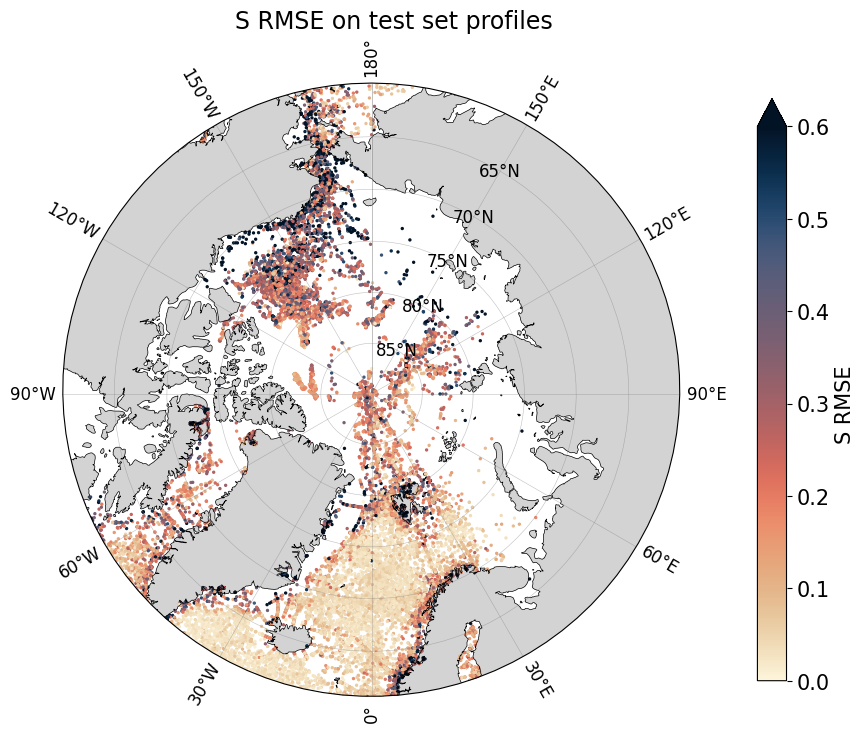

In [18]:
# Extract lat/lon
lats = results['LATITUDE'].values
lons = results['LONGITUDE'].values
values = results['S_rmse_profile'].values

# Create figure and Arctic projection
fig = plt.figure(figsize=(9, 10))
ax = plt.axes(projection=ccrs.NorthPolarStereo())

# Set extent: Northern Hemisphere only
ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())

# Add features
ax.add_feature(
cfeature.LAND
, facecolor='lightgray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.5)
gl.xlocator = plt.MultipleLocator(30)  # Longitude every 30 degrees
gl.ylocator = plt.MultipleLocator(5)  # Latitude every 10 degrees
gl.xlabel_style = {'size': 12}
gl.ylabel_style = {'size': 12}

# Add circle boundary (matching your existing functions)
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

sc = ax.scatter(
    lons, lats,
    c = values,
    s = 2,
    cmap ='cmc.lipari_r',
    transform=ccrs.PlateCarree(),
    vmin=0.0, vmax=0.6
)

cbar = plt.colorbar(sc, ax=ax, orientation='vertical', pad=0.095, shrink=0.6, location='right', extend='max')
cbar.set_label('S RMSE', fontsize=15)
cbar.ax.tick_params(labelsize=15)
plt.title("      S RMSE on test set profiles", fontsize=17)
plt.tight_layout()
path = os.path.join(output_dir, 'S_rmse_map.png')
plt.savefig(path, dpi=350)
plt.show()


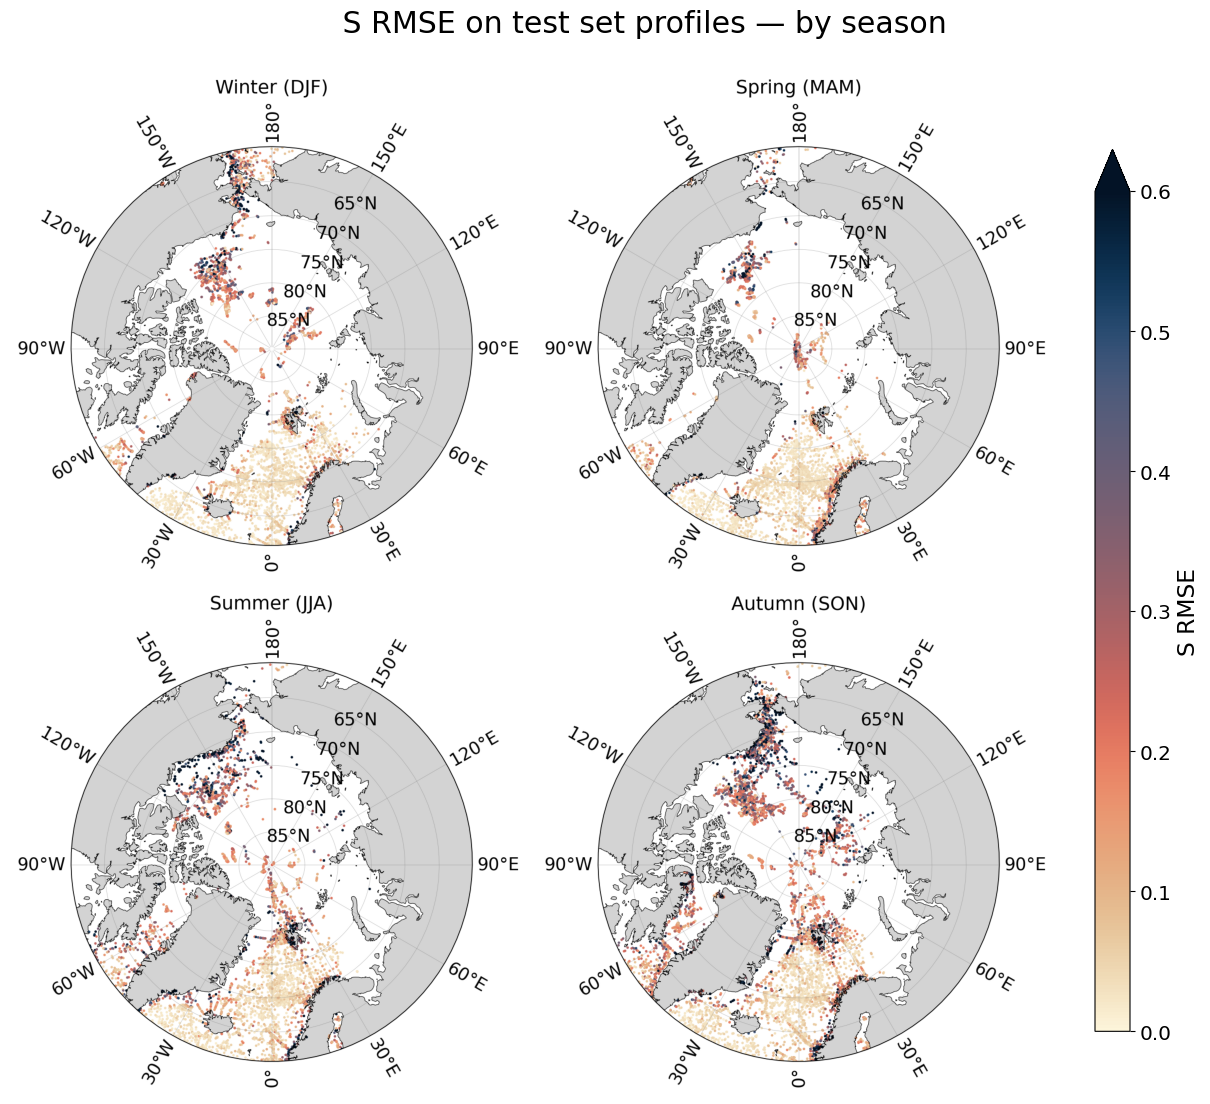

In [14]:

# --- Season masks ---
time_vals = pd.DatetimeIndex(results['TIME'].values)
months = time_vals.month
seasons = {
    'DJF': np.isin(months, [12, 1, 2]),
    'MAM': np.isin(months, [3, 4, 5]),
    'JJA': np.isin(months, [6, 7, 8]),
    'SON': np.isin(months, [9, 10, 11]),
}
season_labels = {'DJF': 'Winter (DJF)', 'MAM': 'Spring (MAM)',
                 'JJA': 'Summer (JJA)', 'SON': 'Autumn (SON)'}

lats = results['LATITUDE'].values
lons = results['LONGITUDE'].values
values_all = results['S_rmse_profile'].values

import io
import matplotlib.cm as _cm
import matplotlib.colors as _mcolors

vmin, vmax = 0.0, 0.6

# Build each panel as a standalone figure, capture as image, then composite
panel_imgs = []
for sname in ['DJF', 'MAM', 'JJA', 'SON']:
    smask = seasons[sname]

    _fig = plt.figure(figsize=(7, 8))
    _ax = plt.axes(projection=ccrs.NorthPolarStereo())
    _ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())
    _ax.add_feature(cfeature.LAND, facecolor='lightgray')
    _ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    _gl = _ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.5)
    _gl.xlocator = plt.MultipleLocator(30)
    _gl.ylocator = plt.MultipleLocator(5)
    _gl.xlabel_style = {'size': 16.8}
    _gl.ylabel_style = {'size': 16.8}
    _theta = np.linspace(0, 2 * np.pi, 100)
    _verts = np.vstack([np.sin(_theta), np.cos(_theta)]).T
    _circle = mpath.Path(_verts * 0.5 + [0.5, 0.5])
    _ax.set_boundary(_circle, transform=_ax.transAxes)
    _ax.scatter(
        lons[smask], lats[smask],
        c=values_all[smask], s=2,
        cmap='cmc.lipari_r',
        transform=ccrs.PlateCarree(),
        vmin=vmin, vmax=vmax
    )
    _ax.set_title(season_labels[sname], fontsize=18)
    _fig.tight_layout()

    buf = io.BytesIO()
    _fig.savefig(buf, dpi=150, bbox_inches='tight')
    buf.seek(0)
    panel_imgs.append(plt.imread(buf))
    plt.close(_fig)

# Composite 2×2
fig, axes = plt.subplots(2, 2, figsize=(14, 14))
for ax, img in zip(axes.flatten(), panel_imgs):
    ax.imshow(img)
    ax.axis('off')

fig.suptitle(('                       '
              'S RMSE on test set profiles — by season'), fontsize=21.6, y=0.95)
fig.subplots_adjust(top=0.97, right=0.87, hspace=-0.25, wspace=0.02)

# Shared colorbar
_sm = _cm.ScalarMappable(cmap='cmc.lipari_r', norm=_mcolors.Normalize(vmin=vmin, vmax=vmax))
_sm.set_array([])
cbar_ax = fig.add_axes([0.90, 0.22, 0.025, 0.63])
cbar = fig.colorbar(_sm, cax=cbar_ax, extend='max')
cbar.set_label('S RMSE', fontsize=16.8)
cbar.ax.tick_params(labelsize=14.4)

path = os.path.join(output_dir, 'S_rmse_map_seasonal.png')
plt.savefig(path, dpi=200, bbox_inches='tight')
plt.show()


PLOT IMPROVEMENT RELATIVE TO GLORYS BY PROFILE

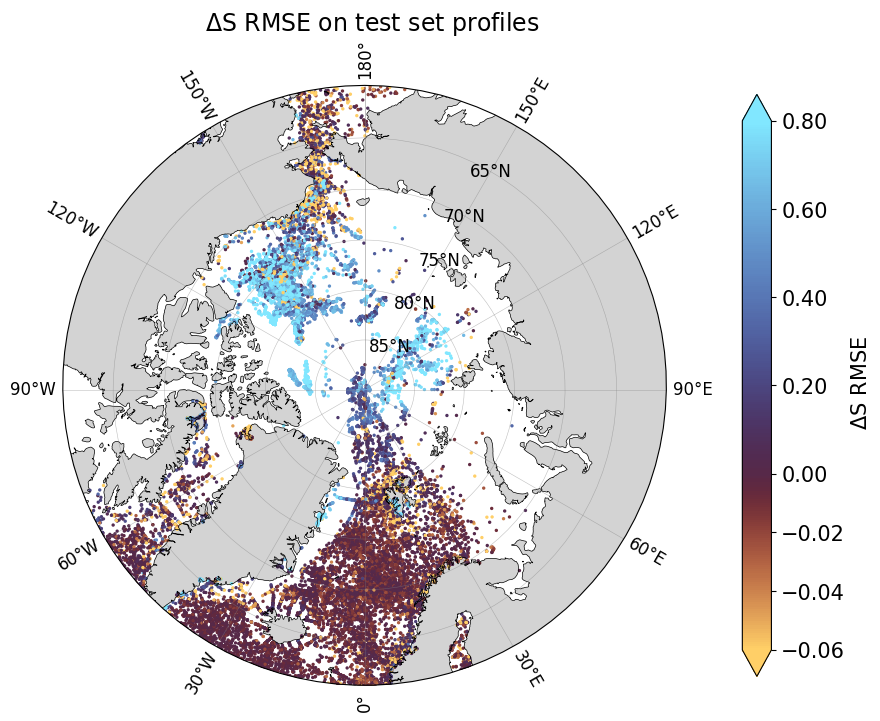

In [19]:

# Extract lat/lon
lats = results['LATITUDE'].values
lons = results['LONGITUDE'].values
values = results['S_glorys_rmse_profile'].values - results['S_rmse_profile'].values

# Create figure and Arctic projection
fig = plt.figure(figsize=(9, 10))
ax = plt.axes(projection=ccrs.NorthPolarStereo())

# Set extent: Northern Hemisphere only
ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())

# Add features
ax.add_feature(
cfeature.LAND
, facecolor='lightgray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.5)
gl.xlocator = plt.MultipleLocator(30)  # Longitude every 30 degrees
gl.ylocator = plt.MultipleLocator(5)  # Latitude every 10 degrees
gl.xlabel_style = {'size': 12}
gl.ylabel_style = {'size': 12}

# Add circle boundary (matching your existing functions)
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

# Remap managua so the center color (originally at 0.5) sits at 1/3 of the colormap
_cf = 1/3
_n = 256
_n_neg = round(_n * _cf)
_cmap_colors = np.vstack([
    cmc.managua(np.linspace(0, 0.5, _n_neg)),
    cmc.managua(np.linspace(0.5, 1.0, _n - _n_neg))
])
cmap_asym = matplotlib.colors.LinearSegmentedColormap.from_list("managua_asym", _cmap_colors)

# Custom norm: maps vmin→0, vcenter=0→1/3, vmax→1
class _AsymNorm(matplotlib.colors.Normalize):
    def __init__(self, vmin, vcenter, vmax, cf=1/3):
        self._vc, self._cf = vcenter, cf
        super().__init__(vmin, vmax)
    def __call__(self, value, clip=None):
        v = np.ma.asarray(value)
        result = np.interp(v.filled(np.nan), [self.vmin, self._vc, self.vmax], [0, self._cf, 1])
        return np.ma.array(result, mask=np.ma.getmaskarray(v))
    def inverse(self, value):
        return np.interp(value, [0, self._cf, 1], [self.vmin, self._vc, self.vmax])

norm = _AsymNorm(vmin=-0.06, vcenter=0, vmax=0.8, cf=1/3)

sc = ax.scatter(
    lons, lats,
    c = values,
    s = 2,
    cmap = cmap_asym,
    transform=ccrs.PlateCarree(),
    norm=norm
)

cbar = plt.colorbar(sc, ax=ax, orientation='vertical', pad=0.095, shrink=0.6, location='right', extend='both')
cbar.set_label(r' $\Delta$S RMSE', fontsize=15)
cbar.set_ticks([-0.06, -0.04, -0.02, 0.0, 0.2, 0.4, 0.6, 0.8])
cbar.ax.tick_params(labelsize=15)
plt.title(r"  $\Delta$S RMSE on test set profiles", fontsize=17)
plt.tight_layout()
path = os.path.join(output_dir, 'S_rmse_improvement_map.png')
plt.savefig(path, dpi=350)
plt.show()


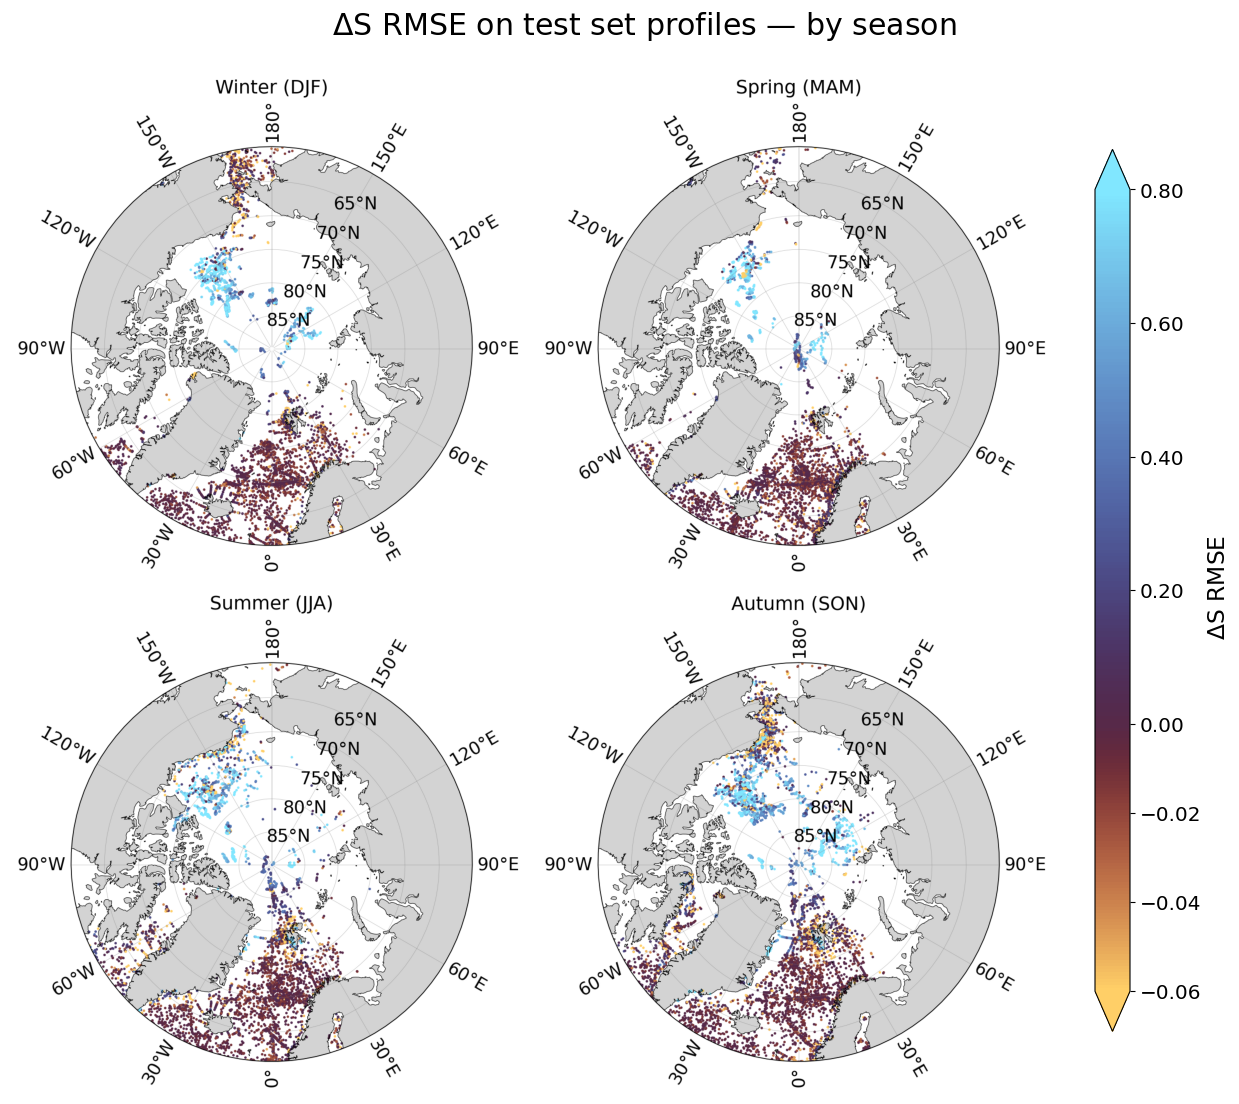

In [22]:

# --- Season masks ---
time_vals = pd.DatetimeIndex(results['TIME'].values)
months = time_vals.month
seasons = {
    'DJF': np.isin(months, [12, 1, 2]),
    'MAM': np.isin(months, [3, 4, 5]),
    'JJA': np.isin(months, [6, 7, 8]),
    'SON': np.isin(months, [9, 10, 11]),
}
season_labels = {'DJF': 'Winter (DJF)', 'MAM': 'Spring (MAM)',
                 'JJA': 'Summer (JJA)', 'SON': 'Autumn (SON)'}

lats = results['LATITUDE'].values
lons = results['LONGITUDE'].values
values_all = results['S_glorys_rmse_profile'].values - results['S_rmse_profile'].values

import io
import matplotlib.cm as _cm
import matplotlib.colors as _mcolors

# Asymmetric managua: zero at 1/3 of the colormap range (same as single-panel)
_cf = 1/3
_n = 256
_n_neg = round(_n * _cf)
_cmap_colors = np.vstack([
    cmc.managua(np.linspace(0, 0.5, _n_neg)),
    cmc.managua(np.linspace(0.5, 1.0, _n - _n_neg))
])
cmap_asym = matplotlib.colors.LinearSegmentedColormap.from_list("managua_asym", _cmap_colors)

class _AsymNorm(matplotlib.colors.Normalize):
    def __init__(self, vmin, vcenter, vmax, cf=1/3):
        self._vc, self._cf = vcenter, cf
        super().__init__(vmin, vmax)
    def __call__(self, value, clip=None):
        v = np.ma.asarray(value)
        result = np.interp(v.filled(np.nan), [self.vmin, self._vc, self.vmax], [0, self._cf, 1])
        return np.ma.array(result, mask=np.ma.getmaskarray(v))
    def inverse(self, value):
        return np.interp(value, [0, self._cf, 1], [self.vmin, self._vc, self.vmax])

norm = _AsymNorm(vmin=-0.06, vcenter=0, vmax=0.8, cf=1/3)

# Build each panel as a standalone figure, capture as image, then composite
panel_imgs = []
for sname in ['DJF', 'MAM', 'JJA', 'SON']:
    smask = seasons[sname]

    _fig = plt.figure(figsize=(7, 8))
    _ax = plt.axes(projection=ccrs.NorthPolarStereo())
    _ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())
    _ax.add_feature(cfeature.LAND, facecolor='lightgray')
    _ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    _gl = _ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.5)
    _gl.xlocator = plt.MultipleLocator(30)
    _gl.ylocator = plt.MultipleLocator(5)
    _gl.xlabel_style = {'size': 16.8}
    _gl.ylabel_style = {'size': 16.8}
    _theta = np.linspace(0, 2 * np.pi, 100)
    _verts = np.vstack([np.sin(_theta), np.cos(_theta)]).T
    _circle = mpath.Path(_verts * 0.5 + [0.5, 0.5])
    _ax.set_boundary(_circle, transform=_ax.transAxes)
    _ax.scatter(
        lons[smask], lats[smask],
        c=values_all[smask], s=2,
        cmap=cmap_asym,
        transform=ccrs.PlateCarree(),
        norm=norm
    )
    _ax.set_title(season_labels[sname], fontsize=18)
    _fig.tight_layout()

    buf = io.BytesIO()
    _fig.savefig(buf, dpi=150, bbox_inches='tight')
    buf.seek(0)
    panel_imgs.append(plt.imread(buf))
    plt.close(_fig)

# Composite 2×2
fig, axes = plt.subplots(2, 2, figsize=(14, 14))
for ax, img in zip(axes.flatten(), panel_imgs):
    ax.imshow(img)
    ax.axis('off')

fig.suptitle(r'                       $\Delta$S RMSE on test set profiles — by season', fontsize=21.6, y=0.95)
fig.subplots_adjust(top=0.97, right=0.87, hspace=-0.25, wspace=0.02)

# Shared colorbar
_sm = _cm.ScalarMappable(cmap=cmap_asym, norm=norm)
_sm.set_array([])
cbar_ax = fig.add_axes([0.90, 0.22, 0.025, 0.63])
cbar = fig.colorbar(_sm, cax=cbar_ax, extend='both')
cbar.set_label(r' $\Delta$S RMSE', fontsize=16.8)
cbar.set_ticks([-0.06, -0.04, -0.02, 0.0, 0.2, 0.4, 0.6, 0.8])
cbar.ax.tick_params(labelsize=14.4)

path = os.path.join(output_dir, 'S_rmse_improvement_map_seasonal.png')
plt.savefig(path, dpi=200, bbox_inches='tight')
plt.show()


PLOT UNCERTAINTIES BY PROFILE

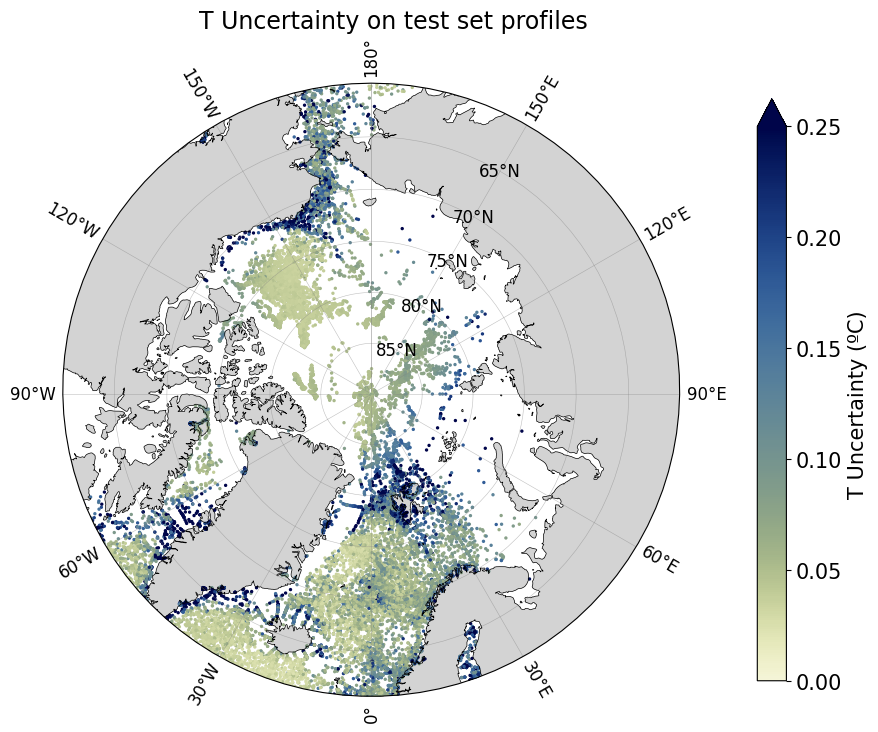

In [20]:
# Extract lat/lon
lats = results['LATITUDE'].values
lons = results['LONGITUDE'].values
values = results['T_uncertainty_profile'].values

# Create figure and Arctic projection
fig = plt.figure(figsize=(9, 10))
ax = plt.axes(projection=ccrs.NorthPolarStereo())

# Set extent: Northern Hemisphere only
ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())

# Add features
ax.add_feature(
cfeature.LAND
, facecolor='lightgray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.5)
gl.xlocator = plt.MultipleLocator(30)  # Longitude every 30 degrees
gl.ylocator = plt.MultipleLocator(5)  # Latitude every 10 degrees
gl.xlabel_style = {'size': 12}
gl.ylabel_style = {'size': 12}

# Add circle boundary (matching your existing functions)
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

cmap_10_100 = matplotlib.colors.LinearSegmentedColormap.from_list(
    "davos_r_10_100",
    cmc.davos_r(np.linspace(0.10, 1.0, 256))
)

sc = ax.scatter(
    lons, lats,
    c=values,
    s=2,
    cmap=cmap_10_100,
    transform=ccrs.PlateCarree(),
    vmin=0.0, vmax=0.25
)

cbar = plt.colorbar(sc, ax=ax, orientation='vertical', pad=0.095, shrink=0.6, location='right', extend='max')
cbar.set_label('T Uncertainty (ºC)', fontsize=15)
cbar.ax.tick_params(labelsize=15)
plt.title("      T Uncertainty on test set profiles", fontsize=17)
plt.tight_layout()
path = os.path.join(output_dir, 'T_uncertainty_map.png')
plt.savefig(path, dpi=350)
plt.show()


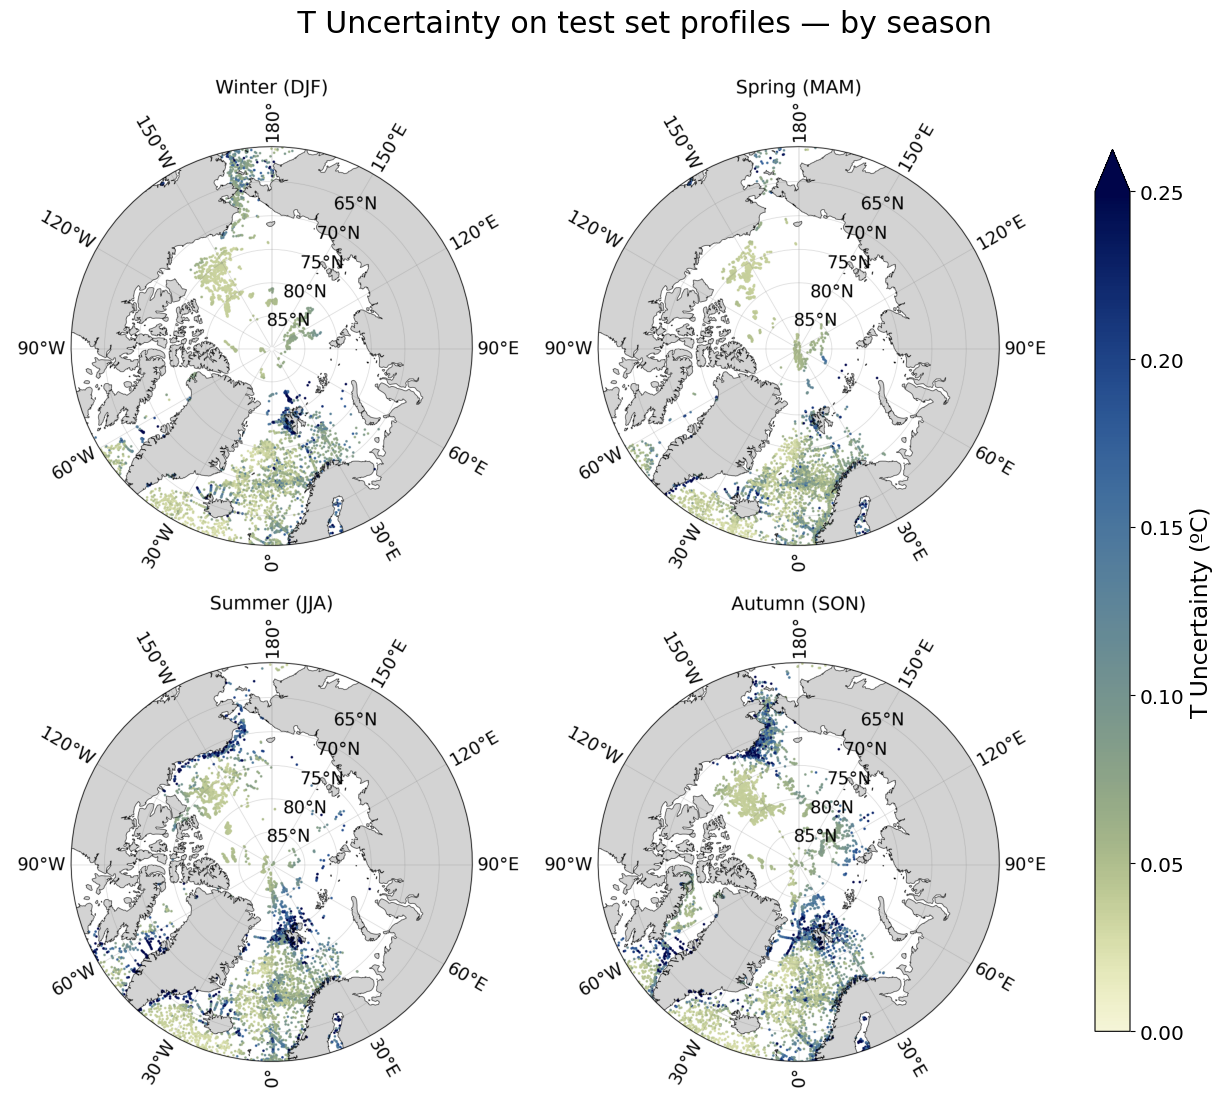

In [18]:

# --- Season masks ---
time_vals = pd.DatetimeIndex(results['TIME'].values)
months = time_vals.month
seasons = {
    'DJF': np.isin(months, [12, 1, 2]),
    'MAM': np.isin(months, [3, 4, 5]),
    'JJA': np.isin(months, [6, 7, 8]),
    'SON': np.isin(months, [9, 10, 11]),
}
season_labels = {'DJF': 'Winter (DJF)', 'MAM': 'Spring (MAM)',
                 'JJA': 'Summer (JJA)', 'SON': 'Autumn (SON)'}

lats = results['LATITUDE'].values
lons = results['LONGITUDE'].values
values_all = results['T_uncertainty_profile'].values

import io
import matplotlib.cm as _cm
import matplotlib.colors as _mcolors

cmap_10_100 = matplotlib.colors.LinearSegmentedColormap.from_list(
    "davos_r_10_100",
    cmc.davos_r(np.linspace(0.10, 1.0, 256))
)
vmin, vmax = 0.0, 0.25

# Build each panel as a standalone figure, capture as image, then composite
panel_imgs = []
for sname in ['DJF', 'MAM', 'JJA', 'SON']:
    smask = seasons[sname]

    _fig = plt.figure(figsize=(7, 8))
    _ax = plt.axes(projection=ccrs.NorthPolarStereo())
    _ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())
    _ax.add_feature(cfeature.LAND, facecolor='lightgray')
    _ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    _gl = _ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.5)
    _gl.xlocator = plt.MultipleLocator(30)
    _gl.ylocator = plt.MultipleLocator(5)
    _gl.xlabel_style = {'size': 16.8}
    _gl.ylabel_style = {'size': 16.8}
    _theta = np.linspace(0, 2 * np.pi, 100)
    _verts = np.vstack([np.sin(_theta), np.cos(_theta)]).T
    _circle = mpath.Path(_verts * 0.5 + [0.5, 0.5])
    _ax.set_boundary(_circle, transform=_ax.transAxes)
    _ax.scatter(
        lons[smask], lats[smask],
        c=values_all[smask], s=2,
        cmap=cmap_10_100,
        transform=ccrs.PlateCarree(),
        vmin=vmin, vmax=vmax
    )
    _ax.set_title(season_labels[sname], fontsize=18)
    _fig.tight_layout()

    buf = io.BytesIO()
    _fig.savefig(buf, dpi=150, bbox_inches='tight')
    buf.seek(0)
    panel_imgs.append(plt.imread(buf))
    plt.close(_fig)

# Composite 2×2
fig, axes = plt.subplots(2, 2, figsize=(14, 14))
for ax, img in zip(axes.flatten(), panel_imgs):
    ax.imshow(img)
    ax.axis('off')

fig.suptitle(('                       '
              'T Uncertainty on test set profiles — by season'), fontsize=21.6, y=0.95)
fig.subplots_adjust(top=0.97, right=0.87, hspace=-0.25, wspace=0.02)

# Shared colorbar
_sm = _cm.ScalarMappable(cmap=cmap_10_100, norm=_mcolors.Normalize(vmin=vmin, vmax=vmax))
_sm.set_array([])
cbar_ax = fig.add_axes([0.90, 0.22, 0.025, 0.63])
cbar = fig.colorbar(_sm, cax=cbar_ax, extend='max')
cbar.set_label('T Uncertainty (ºC)', fontsize=16.8)
cbar.ax.tick_params(labelsize=14.4)

path = os.path.join(output_dir, 'T_uncertainty_map_seasonal.png')
plt.savefig(path, dpi=200, bbox_inches='tight')
plt.show()


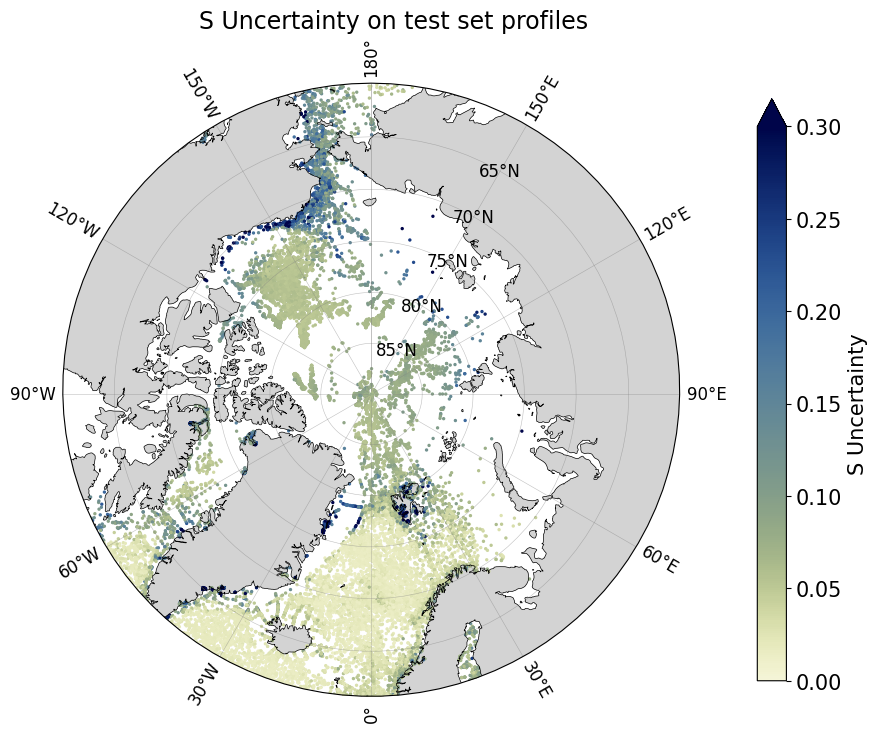

In [21]:
# Extract lat/lon
lats = results['LATITUDE'].values
lons = results['LONGITUDE'].values
values = results['S_uncertainty_profile'].values

# Create figure and Arctic projection
fig = plt.figure(figsize=(9, 10))
ax = plt.axes(projection=ccrs.NorthPolarStereo())

# Set extent: Northern Hemisphere only
ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())

# Add features
ax.add_feature(
cfeature.LAND
, facecolor='lightgray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.5)
gl.xlocator = plt.MultipleLocator(30)  # Longitude every 30 degrees
gl.ylocator = plt.MultipleLocator(5)  # Latitude every 10 degrees
gl.xlabel_style = {'size': 12}
gl.ylabel_style = {'size': 12}

# Add circle boundary (matching your existing functions)
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

cmap_10_100 = matplotlib.colors.LinearSegmentedColormap.from_list(
    "davos_r_10_100",
    cmc.davos_r(np.linspace(0.1, 1.0, 256))
)

sc = ax.scatter(
    lons, lats,
    c = values,
    s = 2,
    cmap = cmap_10_100,
    transform=ccrs.PlateCarree(),
    vmin=0.0, vmax=0.3
)

cbar = plt.colorbar(sc, ax=ax, orientation='vertical', pad=0.095, shrink=0.6, location='right', extend='max')
cbar.set_label('S Uncertainty', fontsize=15)
cbar.ax.tick_params(labelsize=15)
plt.title("      S Uncertainty on test set profiles", fontsize=17)
plt.tight_layout()
path = os.path.join(output_dir, 'S_uncertainty_map.png')
plt.savefig(path, dpi=350)
plt.show()


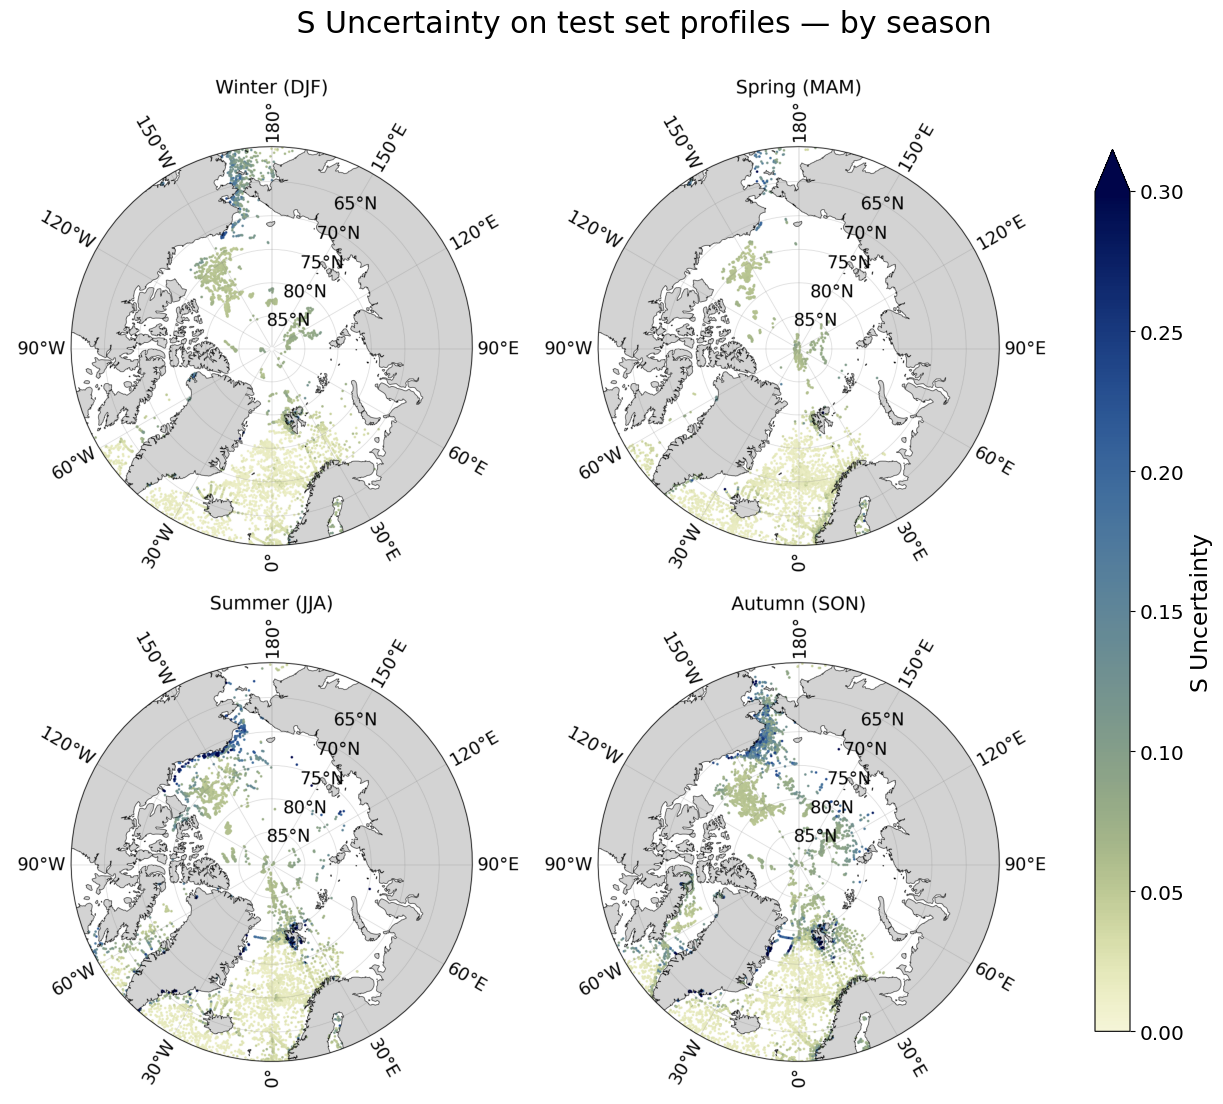

In [20]:

# --- Season masks ---
time_vals = pd.DatetimeIndex(results['TIME'].values)
months = time_vals.month
seasons = {
    'DJF': np.isin(months, [12, 1, 2]),
    'MAM': np.isin(months, [3, 4, 5]),
    'JJA': np.isin(months, [6, 7, 8]),
    'SON': np.isin(months, [9, 10, 11]),
}
season_labels = {'DJF': 'Winter (DJF)', 'MAM': 'Spring (MAM)',
                 'JJA': 'Summer (JJA)', 'SON': 'Autumn (SON)'}

lats = results['LATITUDE'].values
lons = results['LONGITUDE'].values
values_all = results['S_uncertainty_profile'].values

import io
import matplotlib.cm as _cm
import matplotlib.colors as _mcolors

cmap_10_100 = matplotlib.colors.LinearSegmentedColormap.from_list(
    "davos_r_10_100",
    cmc.davos_r(np.linspace(0.1, 1.0, 256))
)
vmin, vmax = 0.0, 0.3

# Build each panel as a standalone figure, capture as image, then composite
panel_imgs = []
for sname in ['DJF', 'MAM', 'JJA', 'SON']:
    smask = seasons[sname]

    _fig = plt.figure(figsize=(7, 8))
    _ax = plt.axes(projection=ccrs.NorthPolarStereo())
    _ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())
    _ax.add_feature(cfeature.LAND, facecolor='lightgray')
    _ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    _gl = _ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.5)
    _gl.xlocator = plt.MultipleLocator(30)
    _gl.ylocator = plt.MultipleLocator(5)
    _gl.xlabel_style = {'size': 16.8}
    _gl.ylabel_style = {'size': 16.8}
    _theta = np.linspace(0, 2 * np.pi, 100)
    _verts = np.vstack([np.sin(_theta), np.cos(_theta)]).T
    _circle = mpath.Path(_verts * 0.5 + [0.5, 0.5])
    _ax.set_boundary(_circle, transform=_ax.transAxes)
    _ax.scatter(
        lons[smask], lats[smask],
        c=values_all[smask], s=2,
        cmap=cmap_10_100,
        transform=ccrs.PlateCarree(),
        vmin=vmin, vmax=vmax
    )
    _ax.set_title(season_labels[sname], fontsize=18)
    _fig.tight_layout()

    buf = io.BytesIO()
    _fig.savefig(buf, dpi=150, bbox_inches='tight')
    buf.seek(0)
    panel_imgs.append(plt.imread(buf))
    plt.close(_fig)

# Composite 2×2
fig, axes = plt.subplots(2, 2, figsize=(14, 14))
for ax, img in zip(axes.flatten(), panel_imgs):
    ax.imshow(img)
    ax.axis('off')

fig.suptitle(('                       '
              'S Uncertainty on test set profiles — by season'), fontsize=21.6, y=0.95)
fig.subplots_adjust(top=0.97, right=0.87, hspace=-0.25, wspace=0.02)

# Shared colorbar
_sm = _cm.ScalarMappable(cmap=cmap_10_100, norm=_mcolors.Normalize(vmin=vmin, vmax=vmax))
_sm.set_array([])
cbar_ax = fig.add_axes([0.90, 0.22, 0.025, 0.63])
cbar = fig.colorbar(_sm, cax=cbar_ax, extend='max')
cbar.set_label('S Uncertainty', fontsize=16.8)
cbar.ax.tick_params(labelsize=14.4)

path = os.path.join(output_dir, 'S_uncertainty_map_seasonal.png')
plt.savefig(path, dpi=200, bbox_inches='tight')
plt.show()


---
---

PLOT PREDICTED PROFILES (save many, show some)

Plotting profiles:   0%|          | 0/500 [00:00<?, ?it/s]

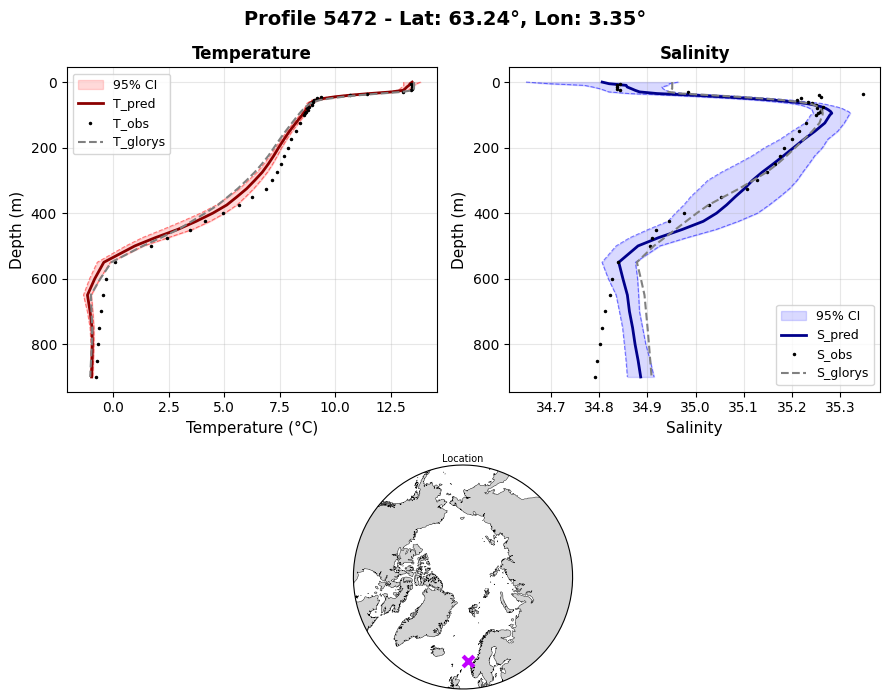

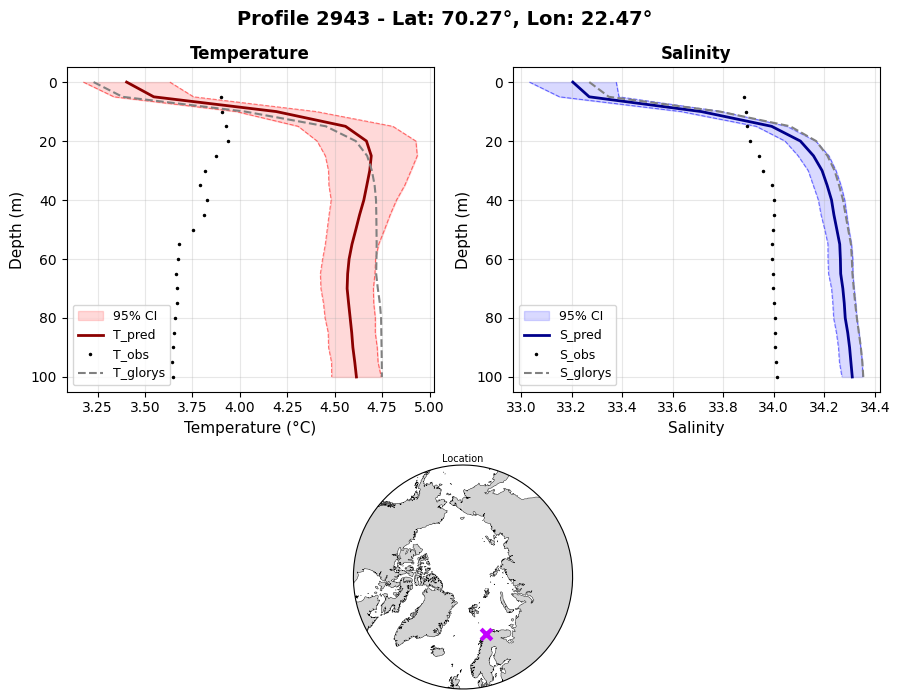

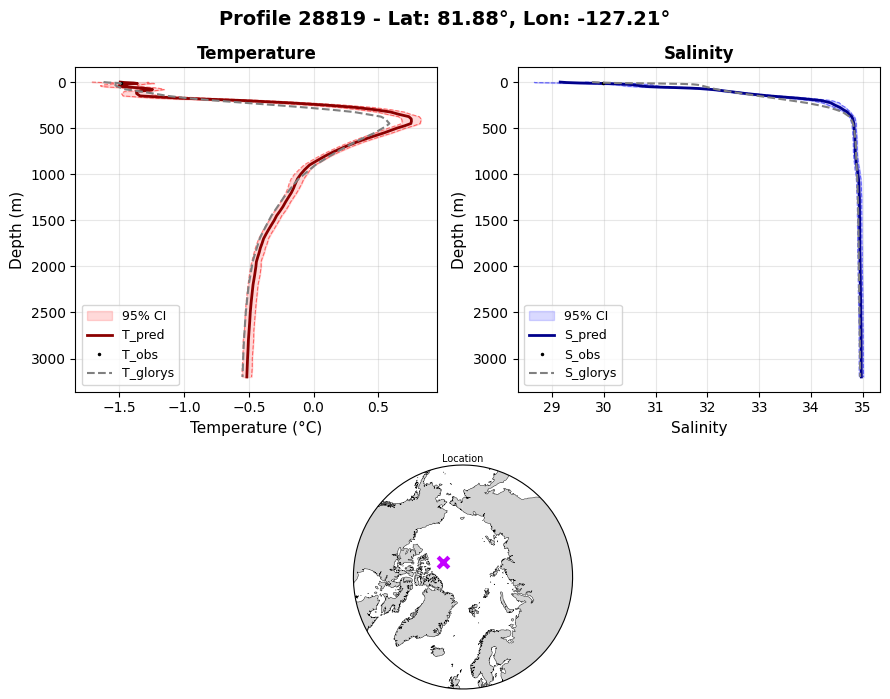

Saved 500 profile plots to ../trained_models/wg_daily_strat_real_only_mcdo_val/AA_winner_model_LSTM_52_46_bs16_lr2e-4_pat6x5_do0.2/plots/profiles


In [ ]:
from tqdm.notebook import tqdm

profiles_dir = os.path.join(output_dir, 'profiles')
os.makedirs(profiles_dir, exist_ok=True)

# Choose 20 random profiles and plot T, S with confidence intervals
n_profiles = len(results['profile'])
n_profiles_to_plot = 500
np.random.seed(42)  # Set seed for reproducibility
random_profiles = np.random.choice(n_profiles, n_profiles_to_plot, replace=False)

# Get depth values
depth_values = results['depth'].values

# Plot each profile
for prof_idx in tqdm(random_profiles, desc='Plotting profiles'):
    # Get location info
    lat = results['LATITUDE'].values[prof_idx]
    lon = results['LONGITUDE'].values[prof_idx]
    
    # Get data for this profile (predictions are already in full scale)
    T_pred = results['T_pred'].values[prof_idx, :]
    # Compute CI bounds using margins (simple: pred ± margin)
    T_ci_lower = T_pred - 1.96 * results['T_uncertainty'].values[prof_idx, :]
    T_ci_upper = T_pred + 1.96 * results['T_uncertainty'].values[prof_idx, :]
    
    S_pred = results['S_pred'].values[prof_idx, :]
    S_ci_lower = S_pred - 1.96 * results['S_uncertainty'].values[prof_idx, :]
    S_ci_upper = S_pred + 1.96 * results['S_uncertainty'].values[prof_idx, :]
    
    # Get in situ observations mask for only real, non augmented data
    mask_real_t = results['TEMP_augs'].values[prof_idx, :] == 0
    mask_real_s = results['PSAL_augs'].values[prof_idx, :] == 0
    mask_real = mask_real_t & mask_real_s

    # Get in situ observations
    T_obs = results['T_obs_insitu'].values[prof_idx, :]
    S_obs = results['S_obs_insitu'].values[prof_idx, :]
    
    # Get GLORYS data
    T_glorys = results['T_glorys'].values[prof_idx, :]
    S_glorys = results['S_glorys'].values[prof_idx, :]
    
    # Create figure with 2 horizontal subplots, leaving room at the bottom for the map
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 7))
    
    # Temperature subplot
    ax1.fill_betweenx(depth_values, T_ci_lower, T_ci_upper, 
                      color='red', alpha=0.15, label='95% CI')
    ax1.plot(T_ci_lower, depth_values, 'r--', linewidth=0.8, alpha=0.5)
    ax1.plot(T_ci_upper, depth_values, 'r--', linewidth=0.8, alpha=0.5)
    ax1.plot(T_pred, depth_values, 'darkred', linewidth=2, label='T_pred')
    ax1.plot(T_obs[mask_real], depth_values[mask_real], 'black', linestyle='none', marker='o', markersize=1.5, label='T_obs')
    ax1.plot(T_glorys, depth_values, 'gray', linestyle='--', linewidth=1.5, label='T_glorys')
    ax1.invert_yaxis()
    ax1.set_xlabel('Temperature (°C)', fontsize=11)
    ax1.set_ylabel('Depth (m)', fontsize=11)
    ax1.set_title('Temperature', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)
    
    # Salinity subplot
    ax2.fill_betweenx(depth_values, S_ci_lower, S_ci_upper, 
                      color='blue', alpha=0.15, label='95% CI')
    ax2.plot(S_ci_lower, depth_values, 'b--', linewidth=0.8, alpha=0.5)
    ax2.plot(S_ci_upper, depth_values, 'b--', linewidth=0.8, alpha=0.5)
    ax2.plot(S_pred, depth_values, 'darkblue', linewidth=2, label='S_pred')
    ax2.plot(S_obs[mask_real], depth_values[mask_real], 'black', linestyle='none', marker='o', markersize=1.5, label='S_obs')
    ax2.plot(S_glorys, depth_values, 'gray', linestyle='--', linewidth=1.5, label='S_glorys')
    ax2.invert_yaxis()
    ax2.set_xlabel('Salinity', fontsize=11)
    ax2.set_ylabel('Depth (m)', fontsize=11)
    ax2.set_title('Salinity', fontsize=12, fontweight='bold')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)
    
    # Overall title with profile info
    fig.suptitle(f'Profile {prof_idx} - Lat: {lat:.2f}°, Lon: {lon:.2f}°', 
                 fontsize=14, fontweight='bold', y=0.98)
    
    # Reserve bottom space for the inset map, then apply tight_layout
    plt.tight_layout(rect=[0, 0.35, 1, 1])
    
    # Small polar location map inset (bottom center of the figure)
    ax_map = fig.add_axes([0.37, 0.01, 0.30, 0.32], projection=ccrs.NorthPolarStereo())
    # [left, bottom, width, height]
    ax_map.set_extent([-180, 180, 55, 90], crs=ccrs.PlateCarree())
    ax_map.add_feature(cfeature.LAND, facecolor='lightgray', zorder=1)
    ax_map.add_feature(cfeature.COASTLINE, linewidth=0.3, zorder=2)
    _theta = np.linspace(0, 2 * np.pi, 100)
    _verts = np.vstack([np.sin(_theta), np.cos(_theta)]).T
    _circle = mpath.Path(_verts * 0.5 + [0.5, 0.5])
    ax_map.set_boundary(_circle, transform=ax_map.transAxes)
    ax_map.scatter(lon, lat, marker='x', color="#C300FF", s=60, linewidths=3,
                   transform=ccrs.PlateCarree(), zorder=5)
    ax_map.set_title('Location', fontsize=7, pad=2)
    
    # Save figure
    path = os.path.join(profiles_dir, f'profile_{prof_idx}_predictions_with_CI.png')
    plt.savefig(path, dpi=350, bbox_inches='tight')
    
    # Show only some of them (first 3)
    if prof_idx in random_profiles[:3]:
        plt.show()
    else:
        plt.close()


print(f"Saved {n_profiles_to_plot} profile plots to {profiles_dir}")
